In [121]:
# En esta versión, cambio de FFNN a LSTM
# Se predicen los RENDIMIENTOS

# Librerías y Módulos

In [ ]:
import sys

# Obtener la lista de kernels
kernels = !jupyter kernelspec list

# Mostrar la lista de kernels para referencia
print(kernels)

# Buscar si 'mi_entorno' está en la lista de kernels
kernel_name = "mi_entorno"
kernel_found = False

for line in kernels:
    if kernel_name in line:
        kernel_found = True
        break

if not kernel_found:
    print(f'Kernel debe ser: {kernel_name}')
    #sys.exit()

print(f'Kernel correcto: {kernel_name}')


In [123]:
#sys.exit('predecir rendimietos y no precios')

In [124]:
sys.path.insert(0, '')
from Clase_Valor_240902 import Valor
from Transversal import leer_activos, leer_parametros, leer_configuracion

## Librerías

In [125]:
import pandas as pd
import numpy as np
import datetime as dt
import itertools
import os
import matplotlib.pyplot as plt
import yfinance as yf

import pickle
import matplotlib.pyplot as plt
import tqdm
import time

from sklearn.model_selection import train_test_split

#import import_ipynb # permite importar módulos ipynb
import warnings
warnings.filterwarnings("ignore")

import mip

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

from sklearn import linear_model

# Parámetros

In [ ]:
sys.exit('POF_CAT cambiar la lógica de los inputs de la red, para que exista una cantidad mínima. Ej: El 50% de los inputs al menos debe ser 1') 

In [127]:
carpeta_input, cofre, seguimiento, saving_step = leer_parametros()
output_level = leer_configuracion()

In [128]:
# Parámetros para construir matrices

cofre = '../Cofre/Red_Neuronal/'
print('Ejemplo')
lista_campos = ['Fibonacci', 'Media_Movil_300_Close', ''] # ejemplo...todos los campos que contengan: PARAMETRO (Filtrar campos)... '' incluye todos los campos
excluir_campos = ['Media_Movil_2_', 'Media_Movil_1_']

Ejemplo


# Lectura de activos

In [129]:
df_activos = leer_activos(carpeta_input)
df_activos

,SIMBOLO,NOMBRE
0,BTC-USD,Bitcoin
1,NFLX,"Netflix, Inc."
2,FCEL,"FuelCell Energy, Inc."
3,DVA,DaVita Inc.
4,AAPL,AAPL
5,DOW,DOW
6,WMT,Walmart
7,TSLA,Tesla
8,AMZN,Amazon
9,BRK-A,Berkshire Hathaway


# Funciones

In [130]:
def pickle_act(file_name, variable = None, mode = 'open', eliminar_si_problemas = False):
    
    """
    Guarda o carga una variable utilizando la biblioteca pickle.

    Parameters:
        - file_path (str): La ruta al archivo pickle.
        - variable: La variable a guardar (si mode='save') o None (si mode='open').
        - mode (str): 'save' para guardar la variable, 'open' para cargar la variable.

    Returns:
        La variable cargada si mode='open' o None si mode='save'.
    """
    
    dic_mode = {'save': 'wb', 'open': 'rb'}
    
    #while True:
    #    try:
    with open(f'{file_name}.pkl', dic_mode[mode]) as file:
        if mode == 'save':
            pickle.dump(variable, file)
            return None
        else:
            #print('file en funciones transversales', f'{file_name}.pkl')
            if eliminar_si_problemas:
                try:
                    variable = pickle.load(file)
                except:
                    os.remove(f'{file_name}.pkl')
                    return pd.DataFrame()
            else:
                variable = pickle.load(file)
            return variable

# Nueva versión (LSTM y RLM dicotómica para búsqueda de hiperparámetros)

Ejemplo básico aleatorio

In [131]:
# Generar datos de ejemplo: secuencia de números
data = np.array([i for i in range(1000)], dtype=float)
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1))

# Definir el tamaño de las secuencias (en este caso simplemente se crean matrices aleatorias)
timesteps = 10
X = []
y = []

for i in range(len(data) - timesteps):
    X.append(data[i:i + timesteps])
    y.append(data[i + timesteps])

X = np.array(X)
y = np.array(y)

# Redimensionar X para que tenga forma (muestras, timesteps, características)
X = np.reshape(X, (X.shape[0], timesteps))

ejecutar_ejemplo = False
if ejecutar_ejemplo:
    # Crear el modelo LSTM
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=False, input_shape=(timesteps, 1)))
    model.add(Dense(units=1))

    # Compilar el modelo
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Entrenar el modelo
    model.fit(X, y, epochs = 10, batch_size = 32)

    # Predecir utilizando el modelo entrenado
    predicciones = model.predict(X)

    # Invertir la normalización para ver los valores originales
    predicciones_originales = scaler.inverse_transform(predicciones)

    print(predicciones_originales[:5])  # Imprimir primeras 5 predicciones

Construir matrices (input y output RRNN)

In [132]:
df_activos

,SIMBOLO,NOMBRE
0,BTC-USD,Bitcoin
1,NFLX,"Netflix, Inc."
2,FCEL,"FuelCell Energy, Inc."
3,DVA,DaVita Inc.
4,AAPL,AAPL
5,DOW,DOW
6,WMT,Walmart
7,TSLA,Tesla
8,AMZN,Amazon
9,BRK-A,Berkshire Hathaway


In [133]:
# Revisar: método construir_matrices(self)

# crea funcion tal que, en el campo name del df, si cualquier campo de la lista_campos es un substring de NAME, entonces se filtra
def filtrar_campos(df, lista_campos, excluir_campos, eliminar_extras = True):
    df['FILTRO'] = False
    for campo in lista_campos:
        df['FILTRO'] = df['FILTRO'] | df['NAME'].str.contains(campo)
    
    for campo in excluir_campos:
        df['FILTRO'] = df['FILTRO'] & ~df['NAME'].str.contains(campo)
    
    for c in ['VALOR', 'DATE', 'Y']:
        if not eliminar_extras:
            break
        df['FILTRO'] = np.where(df['NAME'] == c, False, df['FILTRO'])
        
    return df[df['FILTRO']].drop(columns = 'FILTRO').reset_index(drop = True)


while True:

    # Matrices de input y de output
    cofre0 = '/'.join(cofre.split('/')[:-2]) + '/'
    df_raw_x, df_raw_y = pd.DataFrame(), pd.DataFrame()
    for i in range(len(df_activos)):
        simbolo, nombre = df_activos.loc[i]

        valor = Valor(simbolo, nombre, cofre0) # Si no existe el objeto, se crea 
        if len(valor.raw_x) == 0: # No hay datos que aportar
            continue

        new_raw_x = valor.raw_x.copy()
        new_raw_x['VALOR'] = simbolo
        
        print('SIMBOLO', simbolo, new_raw_x['DATE'].min(), new_raw_x['DATE'].max())
        
        new_raw_y = valor.adj_data[['Date', 'Close']].rename(columns = {'Date': 'DATE', 'Close': 'Y'})
        new_raw_y['VALOR'] = simbolo
        new_raw_y['Y'] = new_raw_y['Y'].pct_change().fillna(0) # Se considera el rendimiento como Y, no el precio
        
        df_raw_x = pd.concat([df_raw_x, new_raw_x], axis = 0)
        df_raw_y = pd.concat([df_raw_y, new_raw_y], axis = 0)
        
        #display(df_raw_x)
        #display(new_raw_y)
        #sys.exit()

    df_raw_x = df_raw_x[['VALOR', 'DATE', 'NAME', 'X']]
    df_raw_x = filtrar_campos(df_raw_x, lista_campos, excluir_campos) # Filtro con lista_campos

    df_raw_x = df_raw_x.pivot_table(index = ['VALOR', 'DATE'], columns = 'NAME', values = 'X').reset_index()

    df = df_raw_x.merge(df_raw_y, on = ['VALOR', 'DATE'], how = 'outer')

    aprobado = True
    for c in list(set(df.columns) - {'DATE', 'VALOR'}):
        #print(c, df[c].min(), df[c].max())
        # Normalizacion
        
        if c != 'Y':
            print(f'NORMALIZACION {c}!!!!')
            df[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())
        
        if len(df[df[c].isna()]) > 0:
            aprobado = False
            print(f'El campo {c} tiene valores nulos')
            display(df[df[c].isna()][['DATE', 'VALOR', c]])
            sys.exit('Salida por campos nulos')
    if aprobado:
        break
    print('B. Espera de completitud de valores en Valor.py: Espera de 30s.')
    time.sleep(30)

df

../Cofre/Valor/BTC-USD
<_io.BufferedReader name='../Cofre/Valor/BTC-USD.pkl'>
SIMBOLO BTC-USD 2014-09-17 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/NFLX
<_io.BufferedReader name='../Cofre/Valor/NFLX.pkl'>
SIMBOLO NFLX 2002-05-23 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/FCEL
<_io.BufferedReader name='../Cofre/Valor/FCEL.pkl'>
SIMBOLO FCEL 1992-06-25 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/DVA
<_io.BufferedReader name='../Cofre/Valor/DVA.pkl'>
SIMBOLO DVA 1995-10-31 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/AAPL
<_io.BufferedReader name='../Cofre/Valor/AAPL.pkl'>
SIMBOLO AAPL 1980-12-12 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/DOW
<_io.BufferedReader name='../Cofre/Valor/DOW.pkl'>
SIMBOLO DOW 2019-03-20 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/WMT
<_io.BufferedReader name='../Cofre/Valor/WMT.pkl'>
SIMBOLO WMT 1972-08-25 00:00:00 2025-01-21 00:00:00
../Cofre/Valor/TSLA
<_io.BufferedReader name='../Cofre/Valor/TSLA.pkl'>
SIMBOLO TSLA 2010-06-29 00:00:00 2025-01-21 00:00:00


,VALOR,DATE,Fibonacci_100_cuerpo,Fibonacci_100_sombra,Fibonacci_150_cuerpo,Fibonacci_150_sombra,Fibonacci_200_cuerpo,Fibonacci_200_sombra,Fibonacci_20_cuerpo,Fibonacci_20_sombra,...,Suavizamiento_Exponencial_0.3_rendimiento,Suavizamiento_Exponencial_0.4_Close,Suavizamiento_Exponencial_0.4_rendimiento,Suavizamiento_Exponencial_0.5_Close,Suavizamiento_Exponencial_0.5_rendimiento,Suavizamiento_Exponencial_0.6_Close,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.7_Close,Suavizamiento_Exponencial_0.7_rendimiento,Y
0,AAPL,1980-12-12,0.553353,0.574557,0.553012,1.0,0.549640,0.460324,0.363636,0.562500,...,0.282579,0.000000,0.280751,0.000000,0.283319,0.000000,0.287796,0.000000,0.293150,0.000000
1,AAPL,1980-12-15,0.553353,0.574557,0.553012,1.0,0.549640,0.460324,0.363636,0.562500,...,0.282579,0.000499,0.280751,0.000498,0.283319,0.000497,0.287796,0.000497,0.293150,-0.052171
2,AAPL,1980-12-16,0.185485,0.220944,0.184862,1.0,0.183735,0.045010,0.266656,0.424023,...,0.198848,0.000489,0.217390,0.000485,0.231866,0.000482,0.244233,0.000478,0.255225,-0.073398
3,AAPL,1980-12-17,0.602613,0.624085,0.602309,1.0,0.598636,0.518494,0.376623,0.581895,...,0.188627,0.000469,0.207078,0.000461,0.221399,0.000455,0.233597,0.000449,0.244423,0.024751
4,AAPL,1980-12-18,0.661742,0.683536,0.661483,1.0,0.657449,0.588318,0.392211,0.605177,...,0.228730,0.000461,0.248571,0.000455,0.264564,0.000451,0.278517,0.000448,0.291127,0.028992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72764,WMT,2025-01-14,0.491644,0.505615,0.507554,1.0,0.513078,0.411982,0.373971,0.592757,...,0.281506,0.965833,0.278593,0.964270,0.279957,0.962769,0.283274,0.960964,0.287547,-0.008085
72765,WMT,2025-01-15,0.494566,0.510156,0.512069,1.0,0.517174,0.416915,0.381818,0.601609,...,0.277936,0.961627,0.275529,0.958685,0.277651,0.955980,0.281937,0.953279,0.287355,0.006058
72766,WMT,2025-01-16,0.493647,0.508335,0.511694,1.0,0.516876,0.416556,0.381283,0.600966,...,0.282246,0.961419,0.280560,0.958779,0.283472,0.956722,0.288487,0.955002,0.294495,-0.000438
72767,WMT,2025-01-17,0.501748,0.517020,0.517703,1.0,0.521641,0.422296,0.389840,0.611266,...,0.282135,0.961125,0.280424,0.958616,0.283180,0.956768,0.287853,0.955226,0.293331,0.007010


Separación de sets

In [134]:
df = df.sort_values(['DATE']).reset_index(drop = True)
df

,VALOR,DATE,Fibonacci_100_cuerpo,Fibonacci_100_sombra,Fibonacci_150_cuerpo,Fibonacci_150_sombra,Fibonacci_200_cuerpo,Fibonacci_200_sombra,Fibonacci_20_cuerpo,Fibonacci_20_sombra,...,Suavizamiento_Exponencial_0.3_rendimiento,Suavizamiento_Exponencial_0.4_Close,Suavizamiento_Exponencial_0.4_rendimiento,Suavizamiento_Exponencial_0.5_Close,Suavizamiento_Exponencial_0.5_rendimiento,Suavizamiento_Exponencial_0.6_Close,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.7_Close,Suavizamiento_Exponencial_0.7_rendimiento,Y
0,WMT,1972-08-25,0.553353,0.574557,0.553012,1.0,0.549640,0.460324,0.363636,0.562500,...,0.282579,0.000000,0.280751,0.000000,0.283319,0.000000,0.287796,0.000000,0.293150,0.000000
1,WMT,1972-08-28,0.553353,0.574557,0.553012,1.0,0.549640,0.460324,0.363636,0.562500,...,0.282579,0.000226,0.280751,0.000226,0.283319,0.000225,0.287796,0.000225,0.293150,-0.003770
2,WMT,1972-08-29,0.277483,0.287279,0.276931,1.0,0.275242,0.122919,0.290909,0.450000,...,0.276528,0.000226,0.276172,0.000225,0.279601,0.000225,0.284648,0.000224,0.290410,-0.011400
3,WMT,1972-08-30,0.277483,0.287279,0.276931,1.0,0.275242,0.122919,0.290909,0.450000,...,0.272854,0.000224,0.272465,0.000224,0.275838,0.000223,0.280825,0.000222,0.286527,0.000000
4,WMT,1972-08-31,0.000764,0.502627,0.000000,1.0,0.000000,0.375843,0.217958,0.534332,...,0.275772,0.000224,0.275779,0.000223,0.279579,0.000222,0.285008,0.000222,0.291163,-0.015407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72764,AMZN,2025-01-21,0.543496,0.564291,0.545226,1.0,0.541901,0.450831,0.436028,0.669893,...,0.293813,0.967947,0.292199,0.968055,0.294779,0.968741,0.299212,0.969483,0.304591,0.021112
72765,DOW,2025-01-21,0.603809,0.628401,0.601436,1.0,0.588213,0.509365,0.376733,0.569877,...,0.293723,0.571693,0.289776,0.572519,0.290510,0.573071,0.293487,0.573248,0.297657,0.013158
72766,BTC-USD,2025-01-21,0.553347,0.556443,0.553006,1.0,0.549634,0.443628,0.373863,0.545679,...,0.287459,0.944897,0.282348,0.944227,0.283417,0.942658,0.287652,0.940753,0.293617,0.040480
72767,DVA,2025-01-21,0.573051,0.578658,0.569343,1.0,0.562819,0.463784,0.377562,0.581533,...,0.300768,0.971550,0.294666,0.975049,0.294244,0.977209,0.296591,0.978314,0.300414,0.022437


In [135]:
df_precios = pd.DataFrame()
for i in range(len(df_activos)):
    simbolo, nombre = df_activos.loc[i]
    valor = Valor(simbolo, nombre, cofre0) # Si no existe el objeto, se crea 
    if len(valor.raw_x) == 0: # No hay datos que aportar
        continue
    df_adj_data = valor.adj_data
    df_adj_data = df_adj_data[['Date', 'Close']].rename(columns = {'Date': 'DATE', 'Close': 'PRECIO'})
    df_adj_data['VALOR'] = simbolo
    
    df_precios = pd.concat([df_precios, df_adj_data])

df_precios = df_precios.reset_index(drop = True)
df_precios['DATE'] = pd.to_datetime(df_precios['DATE'])
df_precios

../Cofre/Valor/BTC-USD
<_io.BufferedReader name='../Cofre/Valor/BTC-USD.pkl'>
../Cofre/Valor/NFLX
<_io.BufferedReader name='../Cofre/Valor/NFLX.pkl'>
../Cofre/Valor/FCEL
<_io.BufferedReader name='../Cofre/Valor/FCEL.pkl'>
../Cofre/Valor/DVA
<_io.BufferedReader name='../Cofre/Valor/DVA.pkl'>
../Cofre/Valor/AAPL
<_io.BufferedReader name='../Cofre/Valor/AAPL.pkl'>
../Cofre/Valor/DOW
<_io.BufferedReader name='../Cofre/Valor/DOW.pkl'>
../Cofre/Valor/WMT
<_io.BufferedReader name='../Cofre/Valor/WMT.pkl'>
../Cofre/Valor/TSLA
<_io.BufferedReader name='../Cofre/Valor/TSLA.pkl'>
../Cofre/Valor/AMZN
<_io.BufferedReader name='../Cofre/Valor/AMZN.pkl'>
../Cofre/Valor/BRK-A
<_io.BufferedReader name='../Cofre/Valor/BRK-A.pkl'>


,DATE,PRECIO,VALOR
0,2014-09-17,0.004191,BTC-USD
1,2014-09-18,0.003890,BTC-USD
2,2014-09-19,0.003618,BTC-USD
3,2014-09-20,0.003747,BTC-USD
4,2014-09-21,0.003655,BTC-USD
...,...,...,...
72764,2025-01-14,0.910763,BRK-A
72765,2025-01-15,0.927934,BRK-A
72766,2025-01-16,0.933869,BRK-A
72767,2025-01-17,0.947153,BRK-A


Train, Test & Control

In [136]:
df['VALOR'].unique()

array(['WMT', 'BRK-A', 'AAPL', 'FCEL', 'DVA', 'AMZN', 'NFLX', 'TSLA',
       'BTC-USD', 'DOW'], dtype=object)

In [137]:
df.columns

Index(['VALOR', 'DATE', 'Fibonacci_100_cuerpo', 'Fibonacci_100_sombra',
       'Fibonacci_150_cuerpo', 'Fibonacci_150_sombra', 'Fibonacci_200_cuerpo',
       'Fibonacci_200_sombra', 'Fibonacci_20_cuerpo', 'Fibonacci_20_sombra',
       'Fibonacci_300_cuerpo', 'Fibonacci_300_sombra', 'Fibonacci_50_cuerpo',
       'Fibonacci_50_sombra', 'Fibonacci_80_cuerpo', 'Fibonacci_80_sombra',
       'Media_Movil_100_Close', 'Media_Movil_100_rendimiento',
       'Media_Movil_10_Close', 'Media_Movil_10_rendimiento',
       'Media_Movil_120_Close', 'Media_Movil_120_rendimiento',
       'Media_Movil_150_Close', 'Media_Movil_150_rendimiento',
       'Media_Movil_200_Close', 'Media_Movil_200_rendimiento',
       'Media_Movil_20_Close', 'Media_Movil_20_rendimiento',
       'Media_Movil_250_Close', 'Media_Movil_250_rendimiento',
       'Media_Movil_300_Close', 'Media_Movil_300_rendimiento',
       'Media_Movil_30_Close', 'Media_Movil_30_rendimiento',
       'Media_Movil_3_Close', 'Media_Movil_3_rendimiento'

In [138]:
df_campos = pd.DataFrame({'NAME': list(df.columns)})
df_campos = filtrar_campos(df_campos, lista_campos, excluir_campos) # filtrar campos es la base de los campos ocupados...todos los modelos vendrán de un subconjunto de estos campos
set_inputs_raw = set(df_campos['NAME'].unique())
print('L', len(set_inputs_raw))
lista_inputs = list(set_inputs_raw) # Son todos los inputs disponibles (no los seleccionados)

print(len(lista_inputs))

df = df[['VALOR', 'DATE'] + lista_inputs + ['Y']]

L 58
58


In [139]:
set_inputs_raw

{'Fibonacci_100_cuerpo',
 'Fibonacci_100_sombra',
 'Fibonacci_150_cuerpo',
 'Fibonacci_150_sombra',
 'Fibonacci_200_cuerpo',
 'Fibonacci_200_sombra',
 'Fibonacci_20_cuerpo',
 'Fibonacci_20_sombra',
 'Fibonacci_300_cuerpo',
 'Fibonacci_300_sombra',
 'Fibonacci_50_cuerpo',
 'Fibonacci_50_sombra',
 'Fibonacci_80_cuerpo',
 'Fibonacci_80_sombra',
 'Media_Movil_100_Close',
 'Media_Movil_100_rendimiento',
 'Media_Movil_10_Close',
 'Media_Movil_10_rendimiento',
 'Media_Movil_120_Close',
 'Media_Movil_120_rendimiento',
 'Media_Movil_150_Close',
 'Media_Movil_150_rendimiento',
 'Media_Movil_200_Close',
 'Media_Movil_200_rendimiento',
 'Media_Movil_20_Close',
 'Media_Movil_20_rendimiento',
 'Media_Movil_250_Close',
 'Media_Movil_250_rendimiento',
 'Media_Movil_300_Close',
 'Media_Movil_300_rendimiento',
 'Media_Movil_30_Close',
 'Media_Movil_30_rendimiento',
 'Media_Movil_3_Close',
 'Media_Movil_3_rendimiento',
 'Media_Movil_4_Close',
 'Media_Movil_4_rendimiento',
 'Media_Movil_50_Close',
 'Media

In [140]:
train_size, test_size, control_size = 0.7, 0.25, 0.05 # Parámetros

In [141]:
df_train, df_control = pd.DataFrame(), pd.DataFrame(),
for valor in df['VALOR'].unique():
    df_valor = df[df['VALOR'] == valor].reset_index(drop = True)
    df_valor = df_valor.sort_values(['DATE']).reset_index(drop = True)
    
    df_train_valor, df_control_valor = train_test_split(df_valor, test_size = control_size, shuffle = False) # shuffle = False -> control son los datos del final, no random
    print(valor, len(df_control_valor) / (len(df_valor)), df_train_valor['DATE'].min().date(), df_control_valor['DATE'].min().date(), df_control_valor['DATE'].max().date())
    df_train = pd.concat([df_train, df_train_valor])
    df_control = pd.concat([df_control, df_control_valor])

display('Train', df_train.head(), 'Control', df_control.head())

WMT 0.050034062523654534 1972-08-25 2022-06-02 2025-01-21
BRK-A 0.050066342326404244 1980-03-17 2022-10-18 2025-01-21
AAPL 0.05001349284879014 1980-12-12 2022-11-01 2025-01-21
FCEL 0.05011583953176442 1992-06-25 2023-06-01 2025-01-21
DVA 0.05004079412564591 1995-10-31 2023-08-03 2025-01-21
AMZN 0.05010768126346016 1997-05-15 2023-08-30 2025-01-21
NFLX 0.05014904436261617 2002-05-23 2023-11-29 2025-01-21
TSLA 0.05021834061135371 2010-06-29 2024-04-26 2025-01-21
BTC-USD 0.05 2014-09-17 2024-07-17 2025-01-21
DOW 0.05037440435670524 2019-03-20 2024-10-03 2025-01-21


'Train'

,VALOR,DATE,Media_Movil_4_rendimiento,Media_Movil_20_rendimiento,Media_Movil_50_rendimiento,Fibonacci_80_cuerpo,Media_Movil_50_Close,Fibonacci_100_sombra,Suavizamiento_Exponencial_0.2_Close,Fibonacci_150_sombra,...,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,Y
0,WMT,1972-08-25,0.293089,0.501415,0.46527,0.545308,0.0,0.574557,0.000000,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000000,0.463509,0.586358,0.000000
1,WMT,1972-08-28,0.293089,0.501415,0.46527,0.545308,0.0,0.574557,0.000228,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000226,0.463509,0.586358,-0.003770
2,WMT,1972-08-29,0.293089,0.501415,0.46527,0.281698,0.0,0.287279,0.000228,1.0,...,0.276931,0.122919,0.432876,0.276528,0.264364,0.284648,0.000225,0.243669,0.567468,-0.011400
3,WMT,1972-08-30,0.293089,0.501415,0.46527,0.281698,0.0,0.287279,0.000227,1.0,...,0.276931,0.122919,0.432876,0.272854,0.264364,0.280825,0.000224,0.243669,0.565556,0.000000
4,WMT,1972-08-31,0.293089,0.501415,0.46527,0.017276,0.0,0.502627,0.000226,1.0,...,0.000000,0.375843,0.432876,0.275772,0.258594,0.285008,0.000223,0.023152,0.566596,-0.015407


'Control'

,VALOR,DATE,Media_Movil_4_rendimiento,Media_Movil_20_rendimiento,Media_Movil_50_rendimiento,Fibonacci_80_cuerpo,Media_Movil_50_Close,Fibonacci_100_sombra,Suavizamiento_Exponencial_0.2_Close,Fibonacci_150_sombra,...,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,Y
12550,WMT,2022-06-02,0.299119,0.452189,0.442732,0.599336,0.537361,0.642183,0.450905,1.0,...,0.609596,0.539750,0.421794,0.277521,0.262892,0.277926,0.442745,0.508566,0.561720,0.016421
12551,WMT,2022-06-03,0.297426,0.452882,0.446213,0.585317,0.536162,0.627720,0.450812,1.0,...,0.594913,0.522763,0.424397,0.286945,0.261651,0.292075,0.444469,0.496875,0.567066,-0.017175
12552,WMT,2022-06-06,0.284686,0.451538,0.445440,0.582436,0.534937,0.624748,0.449191,1.0,...,0.591896,0.519273,0.423319,0.277366,0.254675,0.280903,0.441500,0.494473,0.563728,-0.003591
12553,WMT,2022-06-07,0.283042,0.456156,0.443683,0.572834,0.533615,0.614842,0.447576,1.0,...,0.581840,0.507638,0.423518,0.277201,0.262712,0.283240,0.439227,0.486465,0.563960,-0.012012
12554,WMT,2022-06-08,0.287435,0.449800,0.440749,0.565985,0.532136,0.607776,0.445224,1.0,...,0.574666,0.499339,0.421518,0.273030,0.251897,0.279955,0.435467,0.480753,0.562070,-0.008673


# Algorítmo macro

In [142]:
# Se puede configurar la lstm con los siguientes parámetros:

# 1. número de capas
# 2. número de neuronas en cada capa
# 3. función de activación en cada capa
# 4. Dropout entre capas
# 5. Cerrar o no con una capa densa (fully conected)
# 6. Optimizador (adam, etc)
# 7. Usar bidirectional en cada capa
# 8. cambiar funcion de pérdida (loss)
# 9. ajustar batch size y epochs (en el model.fit)
# 10. LSTM o GRU


## EN RESUMEN
# A. Para cada capa: numero de neuronas, actfunct, dropout [0, 1], usar o no bidirectional (0, 1), es LSTM o GRU
# B. Binario 1 o 0 para cerrar con capa densa
# C. Optimizador (model.compile)
# D. Loss function (model.compile)
# E. Batch size (model.fit)
# F. Dummy para cada uno de los inputs disponibles


# Propuesta:

# En cualquier caso, si por primera vez la red tiene n capas, se agregan los campos de la capa n y fillna 0 a todo lo demás (que antes no existía)

# CAMPOS A: n_neurs_capa_0 (int), actfunct_capa_0 (dummy), dropout_capa_0 (float), bidirectional_capa_0 (bin), LSTM_o_GRU_capa_0 [0 LSTM y 1 GRU] (bin), ...., n_neurs_capa_n (int), actfunct_capa_n (dummy), dropout_capa_n (float), bidirectional_capa_n (bin), LSTM_o_GRU_capa_n (bin), cerrar_con_capa_densa (bin), optimizador (dummy), loss_function (dummy), batch_size (int), epochs (int)
# CAMPOS B-E: [B] cierre_capa_densa (bin), [C] optimizador (dummy), [D] loss_function (dummy), [E] batch_size (int)
# Campos F: cada input disponible (dummy)

In [143]:
# Propuesta de algoritmo

# 0. Comenzar con una arquitectura definida

# while True:
    # 1. Describir la arquitectura definida en la BD arriba para RLM
    # 2. Crear la red neuronal a partir de la descripción de la arquiectura
    # 3. Entrenar la red neuronal (una cantidad definida de epochs)
    # 4. Ocupar el loss de testeo / promedio de loss de testeo para ese tipo de loss registrados en BD_RLM (para "normalizar" por loss) como campo descriptor
    # 5. Agregar en BD_RLM los campos test_error y test_error_normalizado
    # 6. Guardar la red neuronal en BD_RLM
    # 7. Con un learning rate, buscar un nuevo punto y una nueva arquitectura
    # 8. Guardar BD_RLM
    # 9. Si criterio de salida: salir

# Algorítmo

In [144]:
# All LSTM: https://chatgpt.com/c/66f9ed7b-bf70-8000-89b4-e2fe09ce9a9e
# Testeo en: https://chatgpt.com/c/67229d51-50bc-8000-9860-dd92babe59a9
# Manejo del learning_rate: https://chatgpt.com/c/6737cfa0-7b6c-8000-90bb-d2c33a882766

In [145]:
from tensorflow.keras.layers import LeakyReLU

# Opciones disponibles
act_func = {'tanh': 'tanh', 'relu': 'relu', 'sigmoid': 'sigmoid', 'LeakyReLU': LeakyReLU}
act_func_all = act_func.copy()
act_func_all['None'] = None # None: Sin act_func
optimizadores = {'adam': 'adam', 'sgd': 'sgd'}
loss_functions = {'mean_squared_error': 'mean_squared_error', 'mean_absolute_error': 'mean_absolute_error'}

In [146]:
carpeta_LSTM = '../Cofre/LSTM/'

## df_default (inicial)

In [147]:
# df_default

# ver: https://docs.google.com/spreadsheets/d/1zIreFcaWyc4qwJ1QBv1pYw_fqtZQwzpmjoNlFcPP33Q/edit?gid=0#gid=0

df_default = pd.DataFrame()

df_default['N_capas'] = [1] # A

for i in range(df_default['N_capas'][0]): # Para cada capa
    df_default[f'n_neurs_capa_{i}'] = [120] # B1

    for af in act_func.keys(): # B2
        df_default[f'actfunct_capa_{i}_{af}'] = [0]
    df_default[f'actfunct_capa_{i}_tanh'] = 1

    df_default[f'dropout_capa_{i}'] = [0.2] # B3
    df_default[f'bidirectional_capa_{i}'] = [0] # B4
    df_default[f'LSTM_o_GRU_capa_{i}'] = [0] # B5

df_default['cerrar_con_capa_densa'] = [0] # C1.1
df_default['n_neurs_capa_densa'] = 64 # C1.2
for af in act_func_all.keys(): # C2
    df_default[f'actfunct_capa_densa_{af}'] = [0]
df_default[f'actfunct_capa_densa_tanh'] = 1 # Sin función de activación

print('TO DO: También puede ser sin act_fun a la salida')

for opt in optimizadores: # D
    df_default[f'optimizador_{opt}'] = [0]
df_default['optimizador_adam'] = 1

for loss in loss_functions: # E
    df_default[f'loss_function_{loss}'] = [0]
df_default['loss_function_mean_squared_error'] = 1

df_default['batch_size'] = [32] # F

for _input in lista_inputs: # G
    df_default[_input] = [1]

df_default

TO DO: También puede ser sin act_fun a la salida


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
0,1,120,1,0,0,0,0.2,0,0,0,...,1,1,1,1,1,1,1,1,1,1


In [148]:
df_default.to_csv(f'df_default.csv', index = False, sep = ';')

In [149]:

# f: obtener_base_arquitectura
def obtener_base_arquitectura(df_arquitectura):

    N_capas = int(df_arquitectura['N_capas'][0])
    lista_capas = [f'capa_{i}' for i in range(N_capas)]
    
    df_filtro = df_arquitectura.T.reset_index()
    df_filtro.columns = ['NAME', 'VALUE']

    # 1. Capas

    campos_capa = ['n_neurs', 'actfunct', 'dropout', 'bidirectional', 'LSTM_o_GRU']
    all_dict_capas = {}

    for capa in lista_capas: # Para cada capa
        df_filtro_capa = df_filtro[df_filtro['NAME'].str.contains(capa)] # Filtro solo de la capa
        dic_capa = {}
        for c in campos_capa:
            df_c = df_filtro_capa[df_filtro_capa['NAME'].str.contains(c)].reset_index(drop = True) # Filtro del campo en campos_capa
            if c == 'actfunct':
                df_c = df_c[df_c['VALUE'] == 1].reset_index(drop = True)
                
                try:
                    value = df_c['NAME'][0].split('_')[-1]
                except:
                    print('DISPLAYS')
                    display(df_c)
                    display(df_filtro_capa)
                    display(df_filtro)
                    display(df_arquitectura)
                    sys.exit('Error detectado')
            else:
                value = df_c['VALUE'][0]
            dic_capa[c] = value 
        all_dict_capas[capa] = dic_capa

    # 2. Parámetros generales de configuración (que no dependen de la capa)
    df_filtro = df_filtro[~(df_filtro['NAME'].str.contains('capa_') & ~(df_filtro['NAME'].str.contains('capa_densa')))].reset_index(drop = True) # si contiene capa y no contiene capa densa, excluir

    otros_campos = ['N_capas', 'cerrar_con_capa_densa', 'optimizador', 'loss_function', 'batch_size', 'n_neurs_capa_densa', 'actfunct_capa_densa']
    dict_general = {} 
    eliminar_campos = []
    for c in otros_campos:
        
        df_c = df_filtro[df_filtro['NAME'].str.contains(c)].reset_index(drop = True)

        eliminar_campos += list(df_c['NAME'].unique())
        if c in ['optimizador']:
            df_c = df_c[df_c['VALUE'] == 1].reset_index(drop = True)
            value = df_c['NAME'][0].split('_')[-1]
        elif c in ['loss_function']:
            df_c = df_c[df_c['VALUE'] == 1].reset_index(drop = True)
            value = df_c['NAME'][0].split('_')[2:]
            value = '_'.join(value)
        elif c in ['actfunct_capa_densa']:
            df_c = df_c[df_c['VALUE'] == 1].reset_index(drop = True)
            value = df_c['NAME'][0].split('_')[-1]
        else:
            df_c = df_c[df_c['NAME'] == c].reset_index(drop = True)
            value = df_c['VALUE'][0]
            if value % 1 == 0:
                value = int(value)

        dict_general[c] = value
        
    # 3. Inputs
    df_filtro = df_filtro[~df_filtro['NAME'].isin(eliminar_campos)].reset_index(drop = True)
    
    #display('df_filtro0')
    #display(df_filtro)
    df_filtro = df_filtro[df_filtro['VALUE'] == 1].reset_index(drop = True)
    #display('df_filtro1')
    #display(df_filtro)
    lista_inputs = list(df_filtro['NAME'].unique())

    return all_dict_capas, dict_general, lista_inputs 
    

In [150]:
df_train

,VALOR,DATE,Media_Movil_4_rendimiento,Media_Movil_20_rendimiento,Media_Movil_50_rendimiento,Fibonacci_80_cuerpo,Media_Movil_50_Close,Fibonacci_100_sombra,Suavizamiento_Exponencial_0.2_Close,Fibonacci_150_sombra,...,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,Y
0,WMT,1972-08-25,0.293089,0.501415,0.465270,0.545308,0.000000,0.574557,0.000000,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000000,0.463509,0.586358,0.000000
1,WMT,1972-08-28,0.293089,0.501415,0.465270,0.545308,0.000000,0.574557,0.000228,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000226,0.463509,0.586358,-0.003770
2,WMT,1972-08-29,0.293089,0.501415,0.465270,0.281698,0.000000,0.287279,0.000228,1.0,...,0.276931,0.122919,0.432876,0.276528,0.264364,0.284648,0.000225,0.243669,0.567468,-0.011400
3,WMT,1972-08-30,0.293089,0.501415,0.465270,0.281698,0.000000,0.287279,0.000227,1.0,...,0.276931,0.122919,0.432876,0.272854,0.264364,0.280825,0.000224,0.243669,0.565556,0.000000
4,WMT,1972-08-31,0.293089,0.501415,0.465270,0.017276,0.000000,0.502627,0.000226,1.0,...,0.000000,0.375843,0.432876,0.275772,0.258594,0.285008,0.000223,0.023152,0.566596,-0.015407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1390,DOW,2024-09-26,0.293003,0.497273,0.459892,0.708106,0.778786,0.714562,0.740242,1.0,...,0.675984,0.617397,0.439004,0.287982,0.272756,0.287668,0.741541,0.654511,0.589071,0.035579
1391,DOW,2024-09-27,0.313013,0.508104,0.463946,0.738414,0.778582,0.724254,0.747428,1.0,...,0.685671,0.628271,0.443164,0.303492,0.283862,0.305571,0.755197,0.683349,0.597848,0.006579
1392,DOW,2024-09-30,0.313081,0.508114,0.467199,0.720787,0.778673,0.712139,0.754198,1.0,...,0.673562,0.614679,0.442512,0.300386,0.276059,0.298202,0.764555,0.443443,0.598922,-0.008170
1393,DOW,2024-10-01,0.300892,0.507318,0.468583,0.717262,0.778889,0.709715,0.758338,1.0,...,0.671140,0.611960,0.442160,0.291110,0.277292,0.287865,0.766072,0.437076,0.596247,-0.001647


In [151]:
"""
Explicación de ReduceLROnPlateau:
monitor='val_loss': Monitorea la pérdida de validación.
factor=0.5: Reduce la tasa de aprendizaje multiplicándola por 0.5 (puedes ajustar este valor).
patience=5: Espera 5 épocas sin mejora antes de reducir la tasa de aprendizaje.
min_lr=1e-6: La tasa de aprendizaje mínima a la que puede reducirse.
verbose=1: Muestra un mensaje cuando se reduce la tasa de aprendizaje.
"""

"\nExplicación de ReduceLROnPlateau:\nmonitor='val_loss': Monitorea la pérdida de validación.\nfactor=0.5: Reduce la tasa de aprendizaje multiplicándola por 0.5 (puedes ajustar este valor).\npatience=5: Espera 5 épocas sin mejora antes de reducir la tasa de aprendizaje.\nmin_lr=1e-6: La tasa de aprendizaje mínima a la que puede reducirse.\nverbose=1: Muestra un mensaje cuando se reduce la tasa de aprendizaje.\n"

In [152]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU # Llevar arriba
from tensorflow.keras.models import Sequential
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback

In [153]:

class IncreaseLROnPlateau(Callback):
    def __init__(self, monitor='val_loss', factor=1.5, patience=5, min_lr=1e-6, max_lr=1e-2, verbose=1):
        super(IncreaseLROnPlateau, self).__init__()
        self.monitor = monitor
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.verbose = verbose
        self.wait = 0
        self.best_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get(self.monitor)
        if current_loss is None:
            return

        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            current_lr = self.model.optimizer.learning_rate.numpy()
            new_lr = min(current_lr * self.factor, self.max_lr)
            if current_lr < self.max_lr:
                self.model.optimizer.learning_rate.assign(new_lr)
                if self.verbose:
                    print(f"\nEpoch {epoch + 1}: Aumentando learning rate a {new_lr:.6f}")
            self.wait = 0

In [154]:
print('Ancla 0 [funcion crear_LSTM] (ya llamada arriba)')
def crear_LSTM(all_dict_capas, dict_general, lista_inputs):

    print(all_dict_capas)
    print(dict_general)
    print(lista_inputs)

    print('Falta normalizar data (X - min) / (max - min)')

    campos_inputs_df = (set(df_train.columns) - {'VALOR', 'DATE', 'Y'}) # Inputs considerados
    set_inputs_declarados = set(lista_inputs)
    set_inputs = campos_inputs_df.intersection(set_inputs_declarados)
    
    input_shape = len(set_inputs)

    # Inicio
    model = Sequential()
    for i, capa in enumerate(all_dict_capas):
        return_sequences = True
        if i == len(all_dict_capas) - 1:
            return_sequences = False # La última capa no tiene return_sequences
        
        n_neurs, actfunct, dropout, bidirectional, LSTM_o_GRU = all_dict_capas[capa].values()
        
        print('CAPA', i, capa, 'n_neurs', n_neurs, 'actfunct', actfunct, 'dropout', dropout, 'bidirectional', bidirectional, 'LSTM_o_GRU', LSTM_o_GRU)
        n_neurs, bidirectional, LSTM_o_GRU = int(n_neurs), bool(bidirectional), bool(LSTM_o_GRU) # int o booleano dependiendo de los casos
        
        # Creación íntegra de la capa completa
        tipo_capa = LSTM
        if LSTM_o_GRU:
            tipo_capa = GRU
        
        if bidirectional:
            model.add(Bidirectional(tipo_capa(units = n_neurs, return_sequences = return_sequences, input_shape = (input_shape, 1), activation = act_func[actfunct])))
        else:
            model.add(tipo_capa(units = n_neurs, return_sequences = return_sequences, input_shape = (input_shape, 1), activation = act_func[actfunct]))

        # Dropout
        if dropout > 0:
            model.add(Dropout(dropout))
        
        #input_shape = n_neurs

    if dict_general['cerrar_con_capa_densa']:
        model.add(Dense(units = dict_general['n_neurs_capa_densa'], activation = act_func_all[dict_general['actfunct_capa_densa']]))
        print('CAPA DENSA [OPT]', dict_general['n_neurs_capa_densa'], act_func_all[dict_general['actfunct_capa_densa']])
        
    model.add(Dense(units = 1, activation = 'tanh')) # Una sola salida (rendimiento final)...tanh para asegurar valores más suavizados
    print('CAPA FINAL', 'tanh',  1)
    
    if dict_general['optimizador'] == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate = 10 ** -3) # , clipnorm = 1) clipnorm, normaliza datos para que gradiente no explote
    elif dict_general['optimizador'] == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate = 10 ** -3)
    else:
        sys.exit(f"Opt no configurado {dict_general['optimizador']}")
    
    model.compile(optimizer = optimizer, loss = loss_functions[dict_general['loss_function']]) # Optimizador, loss function, learning rate

    # diagrama de la arquitecturaa
    
    # muestra un dibujo de la arquitectura
    print(model.summary())
    #sys.exit()
    
    return model, set_inputs

Ancla 0 [funcion crear_LSTM] (ya llamada arriba)


In [155]:
print('Ancla 1 [Excelente ejemplo de train - testeo]') # Entrainamiento de la red
print('funcion train_LSTM ya llamada arriba')
def train_LSTM(model, set_inputs, dict_general, df_train, epochs = 50, graficar = True, increase = [False, 0.6]):
    X_train = df_train[list(set_inputs)].values # Se crean las matrices X e Y
    Y_train = df_train['Y'].values

    # Configuración del callback para guardar el mejor modelo
    checkpoint = ModelCheckpoint('mejor_modelo.keras', monitor = 'val_loss', save_best_only = True, mode = 'min', verbose = 1)
    
    # Callback para reducir la tasa de aprendizaje si no hay mejora
    if increase[0]:
        cambios_lr = IncreaseLROnPlateau(monitor = 'val_loss', factor = increase[1], patience = 7, min_lr = 1e-10, verbose = 1)
    else:
        cambios_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = increase[1], patience = 7, min_lr = 1e-10, verbose = 1)

    # Ajuste de la red (entrenamiento)
    history = model.fit(X_train, Y_train, epochs = epochs, batch_size = dict_general['batch_size'], validation_split = test_size / (train_size + test_size), verbose = 1, callbacks = [checkpoint, cambios_lr])

    # Ahora, puedes acceder al historial de error de validación así:
    val_loss_per_epoch = history.history['val_loss']
    
    print('val_loss_per_epoch')
    print(val_loss_per_epoch)

    # Si quieres obtener el error de validación de la última época:
    last_val_loss = val_loss_per_epoch[-1]
    print("Error de validación en la última época:", last_val_loss)

    # Graficar la pérdida de entrenamiento y validación para ver la evolución:
    # Hacer un gráfico a la izq y otro a la derecha
    # Crear una figura con 1 fila y 2 columnas
    if graficar:
        fig, axes = plt.subplots(1, 2, figsize = (12, 5))

        # Gráfico de la pérdida de entrenamiento (izquierda)
        axes[0].plot(history.history['loss'], label='Pérdida de Entrenamiento')
        axes[0].set_title('Pérdida de Entrenamiento')
        axes[0].set_ylabel('Pérdida')
        axes[0].set_xlabel('Época')
        axes[0].legend()

        # Gráfico de la pérdida de validación (derecha)
        axes[1].plot(history.history['val_loss'], label='Pérdida de Validación', color='orange')
        axes[1].set_title('Pérdida de Validación')
        axes[1].set_ylabel('Pérdida')
        axes[1].set_xlabel('Época')
        axes[1].legend()

        # Ajustar el layout para evitar solapamiento
        plt.tight_layout()
        plt.show()

    # Usar `mejor_modelo` para hacer predicciones o evaluaciones
    # Cargar el mejor modelo después del entrenamiento
    mejor_modelo_test = load_model('mejor_modelo.keras')
    
    # error de mejor_modelo_test
    
    return mejor_modelo_test, val_loss_per_epoch


def Predict_LSTM(model, set_inputs, df_control):
    X_control = df_control[list(set_inputs)].values
    Y_control = df_control['Y'].values

    loss = model.evaluate(X_control, Y_control)
    print('Loss en control:', loss)

    return loss

Ancla 1 [Excelente ejemplo de train - testeo]
funcion train_LSTM ya llamada arriba


In [156]:
# muestrame cualquier nan en df_train
print('NAN en df_train')
for c in df_train.columns:
    if len(df_train[df_train[c].isna()]) > 0:
        print(c)
        display(df_train[df_train[c].isna()])

NAN en df_train


In [157]:
df_train

,VALOR,DATE,Media_Movil_4_rendimiento,Media_Movil_20_rendimiento,Media_Movil_50_rendimiento,Fibonacci_80_cuerpo,Media_Movil_50_Close,Fibonacci_100_sombra,Suavizamiento_Exponencial_0.2_Close,Fibonacci_150_sombra,...,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,Y
0,WMT,1972-08-25,0.293089,0.501415,0.465270,0.545308,0.000000,0.574557,0.000000,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000000,0.463509,0.586358,0.000000
1,WMT,1972-08-28,0.293089,0.501415,0.465270,0.545308,0.000000,0.574557,0.000228,1.0,...,0.553012,0.460324,0.432876,0.282579,0.264364,0.287796,0.000226,0.463509,0.586358,-0.003770
2,WMT,1972-08-29,0.293089,0.501415,0.465270,0.281698,0.000000,0.287279,0.000228,1.0,...,0.276931,0.122919,0.432876,0.276528,0.264364,0.284648,0.000225,0.243669,0.567468,-0.011400
3,WMT,1972-08-30,0.293089,0.501415,0.465270,0.281698,0.000000,0.287279,0.000227,1.0,...,0.276931,0.122919,0.432876,0.272854,0.264364,0.280825,0.000224,0.243669,0.565556,0.000000
4,WMT,1972-08-31,0.293089,0.501415,0.465270,0.017276,0.000000,0.502627,0.000226,1.0,...,0.000000,0.375843,0.432876,0.275772,0.258594,0.285008,0.000223,0.023152,0.566596,-0.015407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1390,DOW,2024-09-26,0.293003,0.497273,0.459892,0.708106,0.778786,0.714562,0.740242,1.0,...,0.675984,0.617397,0.439004,0.287982,0.272756,0.287668,0.741541,0.654511,0.589071,0.035579
1391,DOW,2024-09-27,0.313013,0.508104,0.463946,0.738414,0.778582,0.724254,0.747428,1.0,...,0.685671,0.628271,0.443164,0.303492,0.283862,0.305571,0.755197,0.683349,0.597848,0.006579
1392,DOW,2024-09-30,0.313081,0.508114,0.467199,0.720787,0.778673,0.712139,0.754198,1.0,...,0.673562,0.614679,0.442512,0.300386,0.276059,0.298202,0.764555,0.443443,0.598922,-0.008170
1393,DOW,2024-10-01,0.300892,0.507318,0.468583,0.717262,0.778889,0.709715,0.758338,1.0,...,0.671140,0.611960,0.442160,0.291110,0.277292,0.287865,0.766072,0.437076,0.596247,-0.001647


## Funciones Etapa 4

In [158]:

# Función categorizar campo (según reglas)
# Basado en https://docs.google.com/spreadsheets/d/1zIreFcaWyc4qwJ1QBv1pYw_fqtZQwzpmjoNlFcPP33Q/edit?gid=0#gid=0

def categorizar_campo(campo_name):

    if campo_name == 'N_capas':
        cat = 'A'

    elif 'actfunct' in campo_name:
        if 'capa_densa' in campo_name:
            cat = 'C2'
        else:
            capa = campo_name.split('_')[2]
            cat = f'B2-{capa}'

    elif 'n_neurs' in campo_name:
        if 'capa_densa' in campo_name:
            cat = 'C1.2'
        else:
            capa = campo_name.split('_')[3]
            cat = f'B1-{capa}'

    elif 'dropout' in campo_name:
        capa = campo_name.split('_')[2]
        cat = f'B3-{capa}'

    elif 'bidirectional' in campo_name:
        capa = campo_name.split('_')[2]
        cat = f'B4-{capa}'

    elif 'LSTM_o_GRU' in campo_name:
        capa = campo_name.split('_')[4]
        cat = f'B5-{capa}'

    elif 'cerrar_con_capa_densa' == campo_name:
        cat = 'C1.1'

    elif 'optimizador' in campo_name:
        cat = 'D'

    elif 'loss_function' in campo_name:
        cat = 'E'

    elif 'batch_size' == campo_name:
        cat = 'F'

    else:
        cat = 'G'

    return cat


def obtener_df_cat(df_arq, cat):

    #print(cat)
    
    df_cat = df_arq[df_arq['CAT'] == cat].reset_index(drop = True)
    
    #display('df_cat V0')
    #display(df_cat)
    
    # 1. min_max_delta, min y max
    min_max_delta, min_value, max_value = df_cat['MIN_MAX_DELTA_EN_UNA_ITER'][0], df_cat['MIN'][0], df_cat['MAX'][0]
    df_cat['DELTA'] = np.where(abs(df_cat['DELTA']) > min_max_delta, np.sign(df_cat['DELTA']) * min_max_delta, df_cat['DELTA']) # Si delta abs supera min_max_delta, acotar
    
    #display(df_cat)
    df_cat['NEW_VALUE'] = df_cat['VALUE'] - df_cat['DELTA']
    
    # min & max
    df_cat['NEW_VALUE'] = np.where(df_cat['NEW_VALUE'] < min_value, min_value, df_cat['NEW_VALUE'])
    df_cat['NEW_VALUE'] = np.where(df_cat['NEW_VALUE'] > max_value, max_value, df_cat['NEW_VALUE'])
    
    # 2. Naturaleza del valor
    naturaleza = df_cat['NATURALEZA_VALOR'][0]
    if naturaleza in ['int', 'bin']: # Lógica bin queda corregida aqui. Anteriormente fue aotada entre 0 & 1 según min & max, luego acá se asigna al enteo más cercano
        df_cat['NEW_VALUE'] = round(df_cat['NEW_VALUE'] + 0.000001).astype(int)
    elif naturaleza == 'float':
        df_cat['NEW_VALUE'] = df_cat['NEW_VALUE'].astype(float)
    
    logica, comentario = df_cat['LÓGICA'][0], df_cat['LÓGICA COMENTARIO'][0]
    
    #print(logica)
    #print(comentario)
    
    if logica == 'max bin': # CAT B2-0, por ejemplo, es B2 para la capa 0
        max_new_value = df_cat['NEW_VALUE'].max()
        df_cats_max = list(df_cat[df_cat['NEW_VALUE'] == max_new_value]['NAME'].unique())
        # Elegir random de los que cumplen
        name_seleccion = np.random.choice(df_cats_max)
        df_cat['NEW_VALUE'] = np.where(df_cat['NAME'] == name_seleccion, 1, 0)
        
        #print('Random cat', name_seleccion)
        #display(df_cat)
    
    return df_cat


def contar_capas_actual(df_arq):
    return len(df_arq[df_arq['CAT'].str.contains('B1')])


def confirmar_capas(df_cat, df_default, df_conf, df_betas, learning_rate_RLM, df_arq):
    N_capas = int(df_cat[df_cat['NAME'] == 'N_capas'].reset_index(drop = True)['NEW_VALUE'][0]) # Cuantas capas requiere la nueva arquitectura
    print('N_capas', N_capas)

    df_capas = df_default[df_default['NAME'].str.contains('0')].reset_index(drop = True) 
    n_capas_origen = contar_capas_actual(df_arq) # Cuantas hay declaradas

    if N_capas == n_capas_origen:
        return df_arq  # No hacer nada, declaración correcta

    elif N_capas < n_capas_origen:
        # Eliminar las capas sobrantes
        df_capas_delete = pd.DataFrame()
        for i in range(N_capas, n_capas_origen):
            df_delete_new = df_capas.copy()
            df_delete_new['NAME'] = df_delete_new['NAME'].str.replace('0', str(i))
            df_capas_delete = pd.concat([df_capas_delete, df_delete_new])
        df_capas_delete['DEL'] = True
        
        df_arq = df_arq.merge(df_capas_delete, on = 'NAME', how = 'left')
        df_arq['DEL'] = df_arq['DEL'].fillna(False)
        df_arq = df_arq[~df_arq['DEL']].reset_index(drop = True)
        df_arq = df_arq.drop(columns = ['DEL'])

    else: # N_capas > n_capas_origen
        
        #print('N_capas > n_capas_origen en confirmar_capas')
        df_capas_add = pd.DataFrame()
        for i in range(n_capas_origen, N_capas):
            df_add_new = df_capas.copy()
            df_add_new['NAME'] = df_add_new['NAME'].str.replace('0', str(i))
            df_capas_add = pd.concat([df_capas_add, df_add_new])  
            
        # Se agregan las capas por default   
        
        #display(df_capas_add)
        df_capas_add['CAT'] = df_capas_add['NAME'].apply(categorizar_campo)
        #display(df_capas_add)
        df_capas_add['CAT_BASE'] = df_capas_add['CAT'].apply(lambda x: x.split('-')[0])
        #display(df_capas_add)
        df_capas_add = df_capas_add.merge(df_conf, on = 'CAT_BASE', how = 'left')
        #display(df_capas_add)
        df_capas_add[['LÓGICA', 'LÓGICA COMENTARIO']] = df_capas_add[['LÓGICA', 'LÓGICA COMENTARIO']].fillna("")
        #display(df_capas_add)

        # Asignar VALUE por defecto si no existe. Si existe, actualizarlo con learning rate y beta

        if 'VALUE' not in df_capas_add.columns:
            df_capas_add['VALUE'] = df_capas_add['DEFAULT_VALUE'] # Este value por default ya cumple las condiciones

        #  Hacer un for CAT unique, y revisar ese subdataframe filtrando CAT, para dejar los valores finales. Considerar LÓGICA y su descripción en lógica comentario

        # Ejecuar descenso del gradiente
        df_capas_add = df_capas_add.merge(df_betas, on = 'NAME', how = 'left')
        df_capas_add['BETA'] = df_capas_add['BETA'].fillna(0)
        
        #display('df_capas_add (evaluar si todos los betas son 0)')
        #print('suma beta', df_capas_add['BETA'].sum())
        #display(df_capas_add)
        df_capas_add['DELTA'] = df_capas_add['BETA'] * learning_rate_RLM
        df_arq = pd.concat([df_arq, df_capas_add]).reset_index(drop = True)      
    
    return df_arq          
    
    
# 4. Ocupar el loss de testeo / promedio de loss de testeo para ese tipo de loss (ej: 'loss_function': 'mean_squared_error', es un tipo de loss) registrados en BD_RLM (para "normalizar" por loss). La RLM debe "predecir" este valor

def update_BD_RLM(BD_RLM, df_arquitectura, best_val_loss, dict_general):
    # Agrega  df_arquitectura, con los valores de ECM test, loss func y ECM_test_norm a BD RLM
    
    #display('update_BD_RLM 0')
    #display(BD_RLM)
    #BD_RLM_new = BD_RLM.iloc[:-1] 
    print('De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función')
    BD_RLM_new = BD_RLM.copy() # De comrobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
    
    #display('update_BD_RLM 1')
    #display(BD_RLM_new)
    
    df_arquitectura['ECM_test'] = best_val_loss
    df_arquitectura['loss_func'] = dict_general['loss_function']
    BD_RLM_new = pd.concat([BD_RLM_new, df_arquitectura])
    
    #display('update_BD_RLM 2')
    #display(BD_RLM_new)
    
    BD_RLM_new_lf = BD_RLM_new[BD_RLM_new['loss_func'] == dict_general['loss_function']].reset_index(drop = True)
    ecm_mean = BD_RLM_new_lf['ECM_test'].mean()
    BD_RLM_new = BD_RLM_new.iloc[:-1]
    
    #display('update_BD_RLM 3')
    #display(BD_RLM_new)
    
    df_arquitectura['ECM_test_norm'] = best_val_loss / ecm_mean
    BD_RLM_new = pd.concat([BD_RLM_new, df_arquitectura])

    #display('update_BD_RLM 4')
    #display(BD_RLM_new)
    
    return BD_RLM_new


# Ejecutar una RLM con BD_RLM_new
def ejecutar_RLM(BD_RLM_new, min_intercept = 10):
    BD_RLM_new_RLM = BD_RLM_new.drop(columns = ['ECM_test', 'loss_func'])
        
    BD_RLM_new_RLM = BD_RLM_new_RLM.fillna(0)
    
    print('ejecutar_RLM')
    display(BD_RLM_new_RLM)

    X, Y = BD_RLM_new_RLM.drop(columns = ['ECM_test_norm']), BD_RLM_new_RLM[['ECM_test_norm']]

    fit_intercept = True # Prueba con intercepto
    if len(X) >= min_intercept:
        fit_intercept = True
    regr = linear_model.LinearRegression(fit_intercept = fit_intercept)
    regr.fit(X, Y)
    betas = list(regr.coef_[0])
    df_betas = pd.DataFrame({'NAME': list(X.columns), 'BETA': betas})
    return df_betas


def generar_nueva_arquitectura(df_arquitectura = None, df_betas = None, learning_rate_RLM = 1000):

    #def arquitectura_limpia(df_arq, learning_rate):
        
        # A partir de un df arquitectura (con value y mov gradiente) (que puede ser un df vacío, n ese caso, se crea df default (primera iteración),
        # Generar un df arquitectura limpio, basado en el contenido de Inputs/POF_CAT.csv
        # df arquitectura es un registro, con varias columnas

    # def arquitectura_limpia

    # PARAMETROS por default
    if df_betas is None:
        df_betas = pd.DataFrame(columns = ['NAME', 'BETA']) # Valor por default en la funcion
    if df_arquitectura is None:
        df_arquitectura = pd.DataFrame() # Valor por default en la funcion
            
    for c in ['ECM_test', 'loss_func', 'ECM_test_norm']: # Limpieza
        if c in df_arquitectura.columns:
            df_arquitectura = df_arquitectura.drop(columns = c)
            
    df_conf = pd.read_csv(f'{carpeta_input}POF_CAT.csv', sep = ';')
    df_default = pd.read_csv(f'{carpeta_input}df_default.csv', sep = ';')
    #display(df_conf)

    if len(df_arquitectura) == 0: # Se crea, sin VALUES inicialmente
        df_inputs = pd.DataFrame({'NAME': lista_inputs})
        df_arquitectura = pd.concat([df_default, df_inputs]).reset_index(drop = True)

    else:
        df_arquitectura = df_arquitectura.T.reset_index()
        df_arquitectura.columns = ['NAME', 'VALUE']

    # En este caso, df_default no tiene valores iniciales. Desde aqui hacia abajo se debe seguir una lógica independiente si es default o no, que actualice los valores y cree una nueva arquitectura
    # Notar siempre que si N_capas aumenta, hay que agregar los campos de la nueva capa por default
    # Si N_capas disminuye, automáticamente no serán considerado los valores de la capa sobrante?? Ej, si pasa de 2 a 1, los valores de la capa 2 no deberían considerarse
    df_arquitectura['CAT'] = df_arquitectura['NAME'].apply(categorizar_campo)
    df_arquitectura['CAT_BASE'] = df_arquitectura['CAT'].apply(lambda x: x.split('-')[0])
    df_arquitectura = df_arquitectura.merge(df_conf, on = 'CAT_BASE', how = 'left')
    df_arquitectura[['LÓGICA', 'LÓGICA COMENTARIO']] = df_arquitectura[['LÓGICA', 'LÓGICA COMENTARIO']].fillna("")

    #display(df_arquitectura)
    # Asignar VALUE por defecto si no existe. Si existe, actualizarlo con learning rate y beta

    if 'VALUE' not in df_arquitectura.columns:
        df_arquitectura['VALUE'] = df_arquitectura['DEFAULT_VALUE'] # Este value por default ya cumple las condiciones

    #  Hacer un for CAT unique, y revisar ese subdataframe filtrando CAT, para dejar los valores finales. Considerar LÓGICA y su descripción en lógica comentario

    # Ejecuar descenso del gradiente

    df_arquitectura = df_arquitectura.merge(df_betas, on = 'NAME', how = 'left').reset_index(drop = True)
    df_arquitectura['BETA'] = df_arquitectura['BETA'].fillna(0)
    
    #print('S BETAS', df_arquitectura['BETA'].sum())
    
    if df_arquitectura['BETA'].sum() == 0:
        print('Distorsion')
        df_arquitectura['BETA'] = np.random.uniform(-1, 1, len(df_arquitectura)) # Distorsión
        
    df_arquitectura['DELTA'] = df_arquitectura['BETA'] * learning_rate_RLM
    
    #print('df arq betas')
    #display(df_arquitectura.tail(30))

    df_new_arquitectura = pd.DataFrame()

    # Primero, df_cat = obtener_df_cat(df_arq, cat) se ejecuta para A, para conocer el número final de capas de la red

    df_cat = obtener_df_cat(df_arquitectura, 'A')
    df_new_arquitectura = pd.concat([df_new_arquitectura, df_cat])

    # ANCLA 3
    df_arquitectura = confirmar_capas(df_cat, df_default, df_conf, df_betas, learning_rate_RLM, df_arquitectura) # Agrega o quita campos de capas según N_capas nuevo
    
    #df_arquitectura.to_csv(f'df_arquitectura_revision.csv', index = False, sep = ';')
    
    #print(df_arquitectura['CAT'].unique())
    #sys.exit()

    for cat in df_arquitectura['CAT'].unique():
        if cat == "A": # "A" ya fue agregado
            continue
        #print(cat)
        df_cat = obtener_df_cat(df_arquitectura, cat)
        
        #print(cat)
        #display(df_cat)
        df_new_arquitectura = pd.concat([df_new_arquitectura, df_cat])
    
    #sys.exit()
        
    df_new_arquitectura = df_new_arquitectura.reset_index(drop = True)

    # Retornar esto en la función, es la nueva arquitectura que cumple con todas las condiciones
    df_new_arquitectura_clean = df_new_arquitectura[['NAME', 'NEW_VALUE']].T
    df_new_arquitectura_clean.columns = df_new_arquitectura_clean.iloc[0]
    df_new_arquitectura_clean = df_new_arquitectura_clean.iloc[1:]
    return df_new_arquitectura_clean


# Ejecución

In [159]:
learning_rate_RLM = 100 # Parámetros
iteraciones_arquitecturas = 10
epochs = 10 # Para cada red neuronal
graficar = True

,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
0,1,120,1,0,0,0,0.2,0,0,0,...,1,1,1,1,1,1,1,1,1,1


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 120.0, 'actfunct': 'tanh', 'dropout': 0.2, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_squared_error', 'batch_size': 32, 'n_neurs_capa_densa': 64, 'actfunct_capa_densa': 'tanh'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_20_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_80_cuerpo', 'Media_Movil_50_Close', 'Fibonacci_100_sombra', 'Suavizamiento_Exponencial_0.2_Close', 'Fibonacci_150_sombra', 'Media_Movil_300_Close', 'Media_Movil_200_Close', 'Suavizamiento_Exponencial_0.1_Close', 'Media_Movil_30_Close', 'Media_Movil_80_rendimiento', 'Media_Movil_10_Close', 'Media_Movil_250_Close', 'Media_Movil_20_Close', 'Media_Movil_30_rendimiento', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_100_cuerpo', 'Media_Movil_10_rendimiento',

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 120)            │        58,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,681 (229.22 KB)

 Trainable params: 58,681 (229.22 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011
Epoch 1: val_loss improved from inf to 0.00107, saving model to mejor_modelo.keras
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - loss: 0.0011 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 2/10
1591/1592 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.5077e-04
Epoch 2: val_loss improved from 0.00107 to 0.00099, saving model to mejor_modelo.keras
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - loss: 9.5078e-04 - val_loss: 9.9493e-04 - learning_rate: 0.0010
Epoch 3/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.9442e-04
Epoch 3: val_loss improved from 0.00099 to 0.00098, saving model to mejor_modelo.keras
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - loss: 8.9445e-04 - val_loss: 9.8002e-04 - learning_rate: 0.0010
Epoch 4/10
1590/1592 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011
Epoch 4: val_loss improved from 0.00098 to 0.00097, saving model to mejor_modelo.keras
1592/1592 ━━━━━━━━

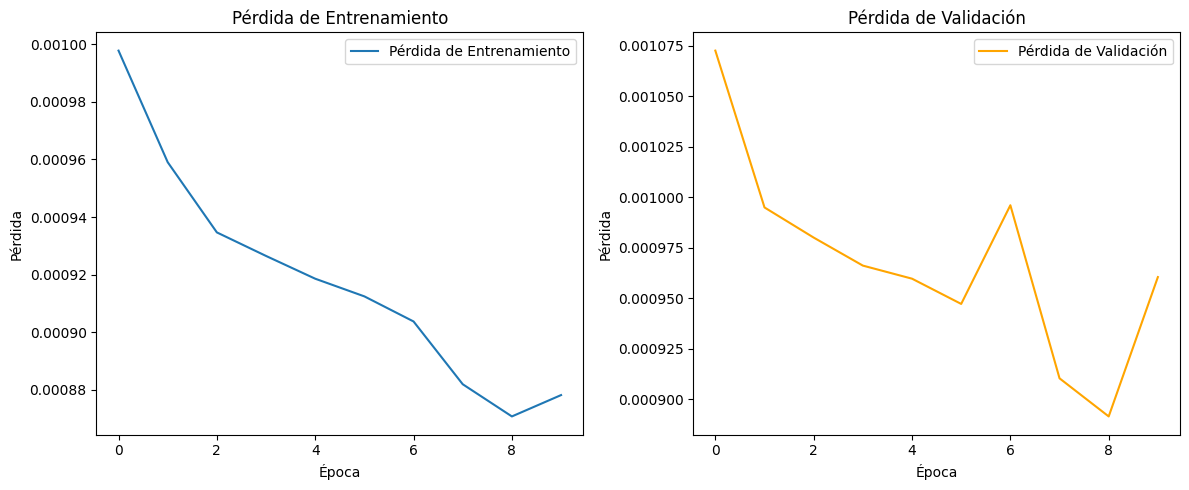

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm
0,1,120,1,0,0,0,0.2,0,0,0,...,1,1,1,1,1,1,1,1,1,1.0


Distorsion
N_capas 2


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,...,0.0,1.0,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 110.0, 'actfunct': 'tanh', 'dropout': 0.5, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}, 'capa_1': {'n_neurs': 60.0, 'actfunct': 'sigmoid', 'dropout': 0.2, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 2, 'cerrar_con_capa_densa': 0, 'optimizador': 'sgd', 'loss_function': 'mean_absolute_error', 'batch_size': 42, 'n_neurs_capa_densa': 74, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Media_Movil_50_Close', 'Fibonacci_100_sombra', 'Fibonacci_150_sombra', 'Media_Movil_300_Close', 'Suavizamiento_Exponencial_0.1_Close', 'Media_Movil_80_rendimiento', 'Media_Movil_10_Close', 'Media_Movil_250_Close', 'Media_Movil_20_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Media_Movil_10_rendimiento', 'Suavizamiento_Exponencial_0.4_rendimiento', 'Suavizamiento_Exponencial_0.5_rendimien

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 27, 110)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 27, 110)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60)             │        41,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,381 (353.05 KB)

 Trainable params: 90,381 (353.05 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1211/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2086
Epoch 1: val_loss improved from inf to 0.02136, saving model to mejor_modelo.keras
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.2086 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 2/10
1212/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1704
Epoch 2: val_loss did not improve from 0.02136
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.1704 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 3/10
1212/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1472
Epoch 3: val_loss did not improve from 0.02136
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.1472 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 4/10
1211/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1269
Epoch 4: val_loss did not improve from 0.02136
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - loss: 0.1268 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 5/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - lo

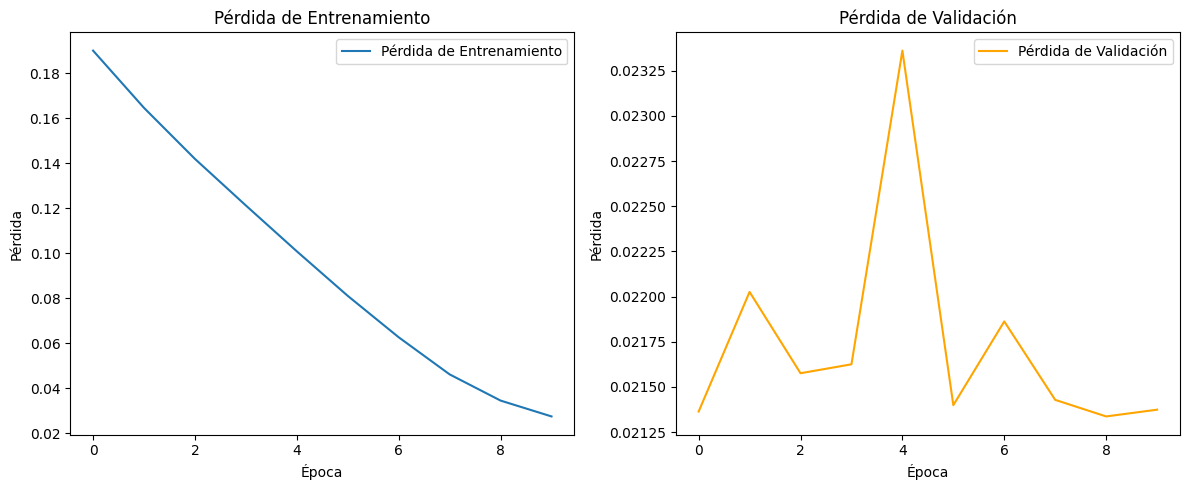

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,...,1.0,1.0,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0


Distorsion
N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 100.0, 'actfunct': 'tanh', 'dropout': 0.0, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'sgd', 'loss_function': 'mean_squared_error', 'batch_size': 52, 'n_neurs_capa_densa': 84, 'actfunct_capa_densa': 'None'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_20_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_80_cuerpo', 'Fibonacci_100_sombra', 'Suavizamiento_Exponencial_0.2_Close', 'Media_Movil_200_Close', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Media_Movil_30_rendimiento', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_100_cuerpo', 'Media_Movil_150_rendimiento', 'Fibonacci_200_cuerpo', 'Suavizamiento_Exponencial_0.7_rendimiento', 'Fibonacci_300_cuerpo', 'Fibonacci_20_cuerpo', 'Fibonacci_50_sombra', 'Suavizamiento_Exponencial_0.4_Close', 'Medi

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
978/980 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.6866e-04
Epoch 1: val_loss improved from inf to 0.00108, saving model to mejor_modelo.keras
980/980 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 9.6870e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 2/10
979/980 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010
Epoch 2: val_loss improved from 0.00108 to 0.00108, saving model to mejor_modelo.keras
980/980 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0010 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/10
978/980 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.4144e-04
Epoch 3: val_loss improved from 0.00108 to 0.00108, saving model to mejor_modelo.keras
980/980 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 9.4156e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/10
979/980 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.2322e-04
Epoch 4: val_loss improved from 0.00108 to 0.00107, saving model to mejor_modelo.keras
980/980 ━━━━━━━━━━━━━━━━━━━━ 15s 16m

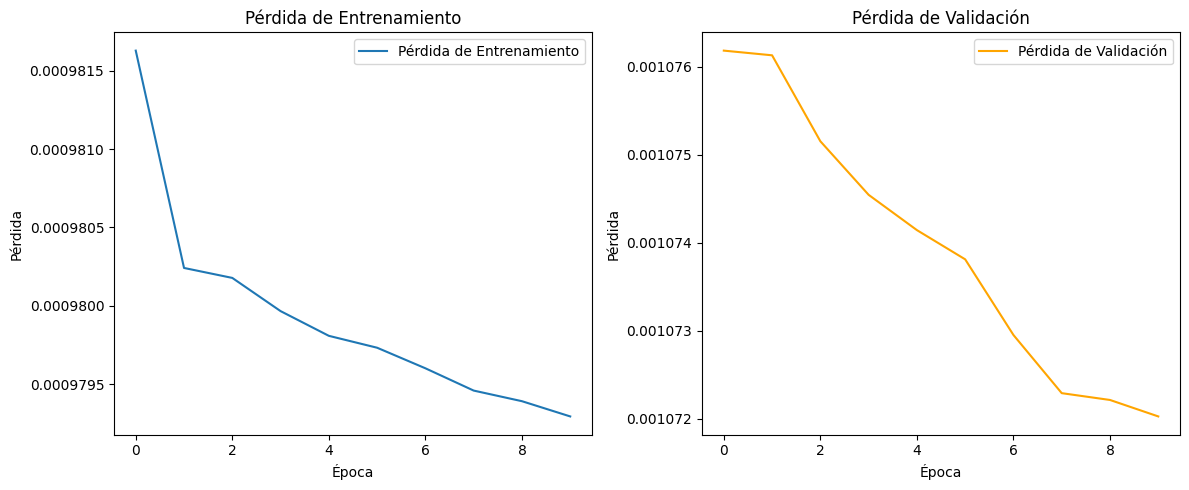

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.0,1.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,...,1.0,1.00000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.09193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 98.0, 'actfunct': 'tanh', 'dropout': 0.011711790765109129, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_squared_error', 'batch_size': 51, 'n_neurs_capa_densa': 83, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_20_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_80_cuerpo', 'Fibonacci_100_sombra', 'Suavizamiento_Exponencial_0.2_Close', 'Media_Movil_200_Close', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Media_Movil_30_rendimiento', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_100_cuerpo', 'Media_Movil_150_rendimiento', 'Fibonacci_200_cuerpo', 'Suavizamiento_Exponencial_0.7_rendimiento', 'Fibonacci_300_cuerpo', 'Fibonacci_20_cuerpo', 'Fibonacci_50_sombra', 'Suavizamiento_Exponencial_

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 98)             │        39,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 98)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,299 (153.51 KB)

 Trainable params: 39,299 (153.51 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
996/999 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011
Epoch 1: val_loss improved from inf to 0.00102, saving model to mejor_modelo.keras
999/999 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 0.0011 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 2/10
999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.7346e-04
Epoch 2: val_loss did not improve from 0.00102
999/999 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 9.7344e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 3/10
999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.6858e-04
Epoch 3: val_loss did not improve from 0.00102
999/999 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 9.6856e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 4/10
996/999 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.6186e-04
Epoch 4: val_loss improved from 0.00102 to 0.00097, saving model to mejor_modelo.keras
999/999 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 9.6177e-04 - val_loss: 9.6840e-04 - learning_rate: 0.0010
Epoch 5

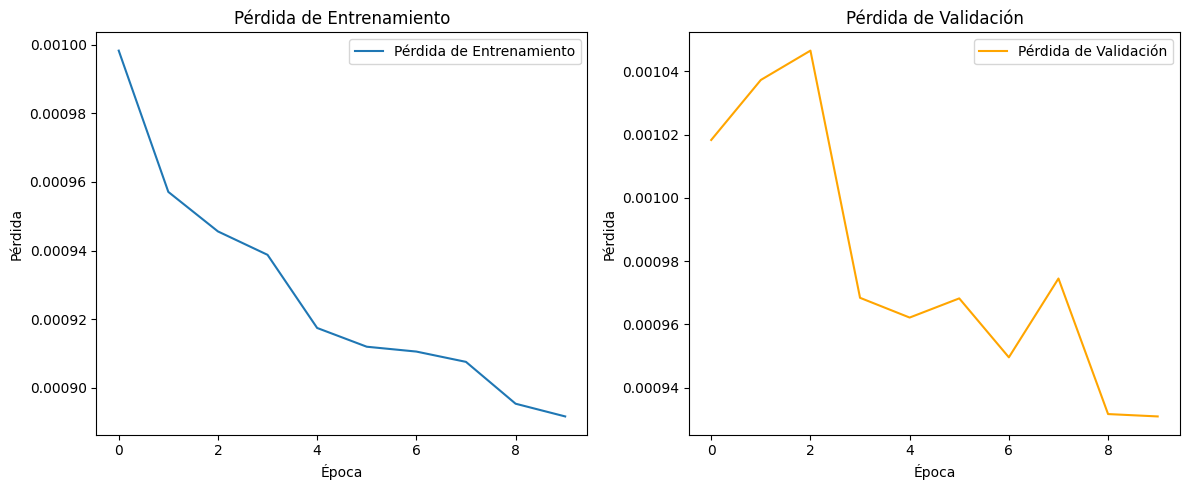

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 95.0, 'actfunct': 'relu', 'dropout': 0.02473182715742106, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_absolute_error', 'batch_size': 49, 'n_neurs_capa_densa': 81, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 95.0, 'actfunct': 'relu', 'dropout

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 95)             │        36,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 95)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            96 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,956 (144.36 KB)

 Trainable params: 36,956 (144.36 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1035/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0186
Epoch 1: val_loss improved from inf to 0.02132, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0186 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 2/10
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0182
Epoch 2: val_loss did not improve from 0.02132
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0182 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 3/10
1038/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0180
Epoch 3: val_loss improved from 0.02132 to 0.02131, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0180 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 4/10
1036/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0179
Epoch 4: val_loss improved from 0.02131 to 0.02121, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0179 - val_loss: 0.0212 - lear

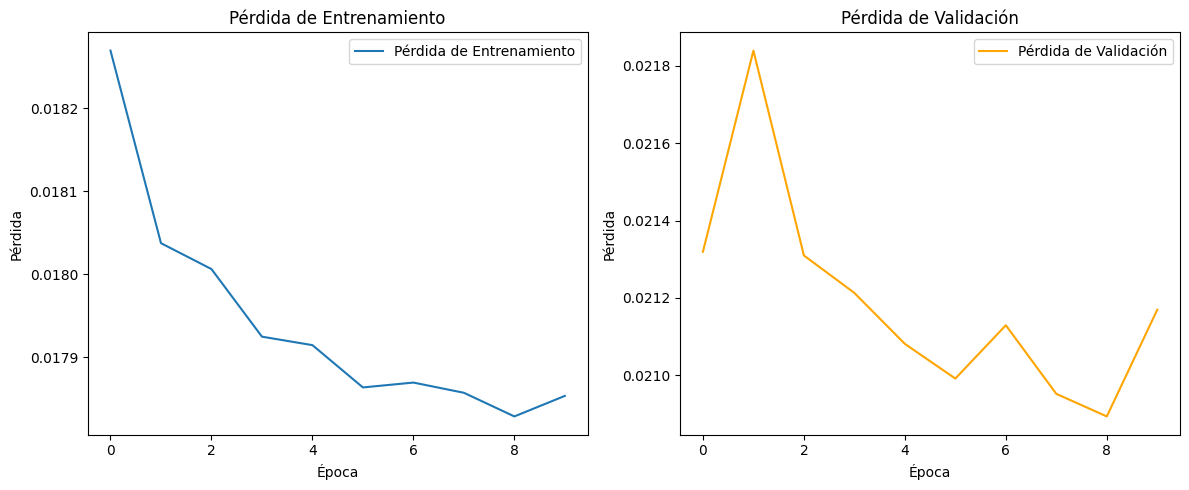

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 93.0, 'actfunct': 'sigmoid', 'dropout': 0.04280678270124429, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_absolute_error', 'batch_size': 48, 'n_neurs_capa_densa': 80, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 93.0, 'actfunct': 'sigmoid', 'd

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 93)             │        35,340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 93)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            94 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,434 (138.41 KB)

 Trainable params: 35,434 (138.41 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0703
Epoch 1: val_loss improved from inf to 0.02364, saving model to mejor_modelo.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0703 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 2/10
1061/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0245
Epoch 2: val_loss improved from 0.02364 to 0.02199, saving model to mejor_modelo.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0245 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 3/10
1059/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0202
Epoch 3: val_loss improved from 0.02199 to 0.02145, saving model to mejor_modelo.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0202 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 4/10
1059/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0190
Epoch 4: val_loss did not improve from 0.02145
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0190 - val_loss: 0.0217 - lear

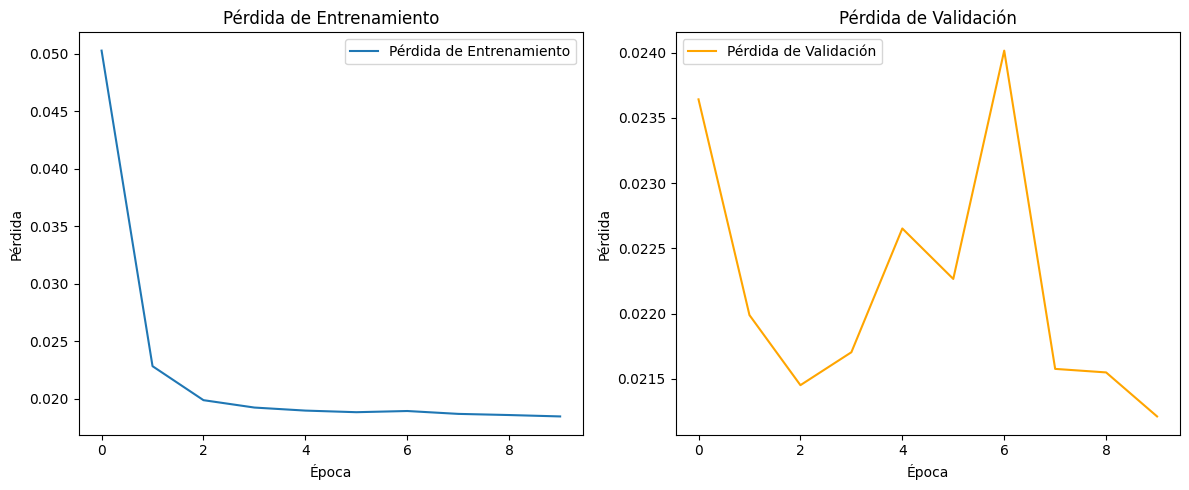

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,1.003062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,92.0,0.0,1.0,0.0,0.0,0.03962,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 92.0, 'actfunct': 'relu', 'dropout': 0.03961999774872831, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_squared_error', 'batch_size': 49, 'n_neurs_capa_densa': 78, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 92.0, 'actfunct': 'relu', 'dropout'

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 92)             │        34,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 92)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,685 (135.49 KB)

 Trainable params: 34,685 (135.49 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1033/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.9335e-04
Epoch 1: val_loss improved from inf to 0.00107, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 9.9323e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 2/10
1037/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.8692e-04
Epoch 2: val_loss improved from 0.00107 to 0.00104, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 9.8681e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 3/10
1035/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1423e-04
Epoch 3: val_loss improved from 0.00104 to 0.00103, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 9.1443e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 4/10
1037/1040 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5924e-04
Epoch 4: val_loss improved from 0.00103 to 0.00101, saving model to mejor_modelo.keras
1040/1040 ━━━━━━━━━━━━━

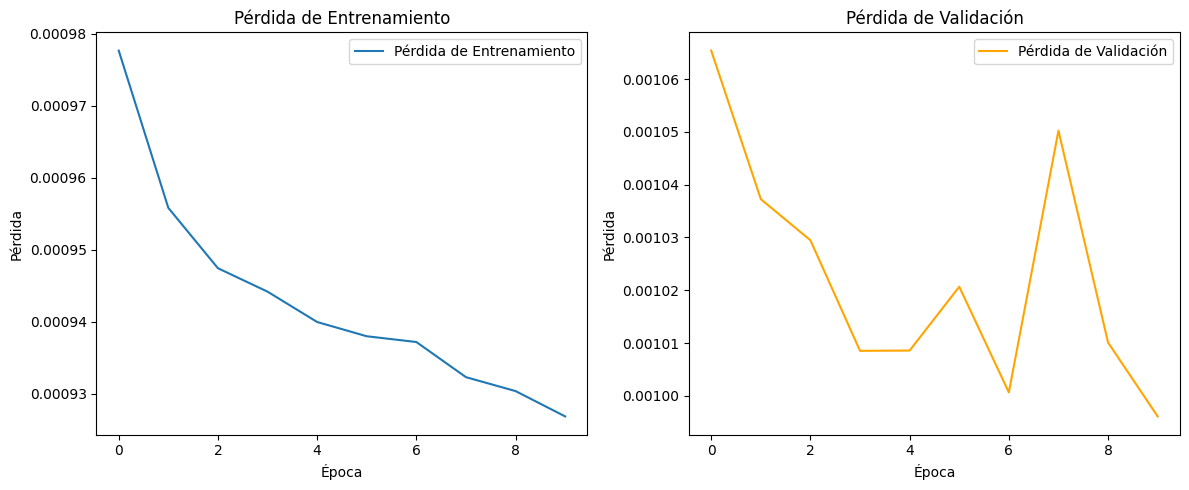

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,1.003062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,92.0,0.0,1.0,0.0,0.0,0.039620,0.0,0.0,0.0,...,1.0,1.024132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.03933,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 91.0, 'actfunct': 'relu', 'dropout': 0.0393299497388962, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_absolute_error', 'batch_size': 47, 'n_neurs_capa_densa': 79, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 91.0, 'actfunct': 'relu', 'dropout'

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 91)             │        33,852 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 91)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            92 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,944 (132.59 KB)

 Trainable params: 33,944 (132.59 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1081/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190
Epoch 1: val_loss improved from inf to 0.02165, saving model to mejor_modelo.keras
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0190 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 2/10
1082/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0183
Epoch 2: val_loss improved from 0.02165 to 0.02125, saving model to mejor_modelo.keras
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0183 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 3/10
1082/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0178
Epoch 3: val_loss did not improve from 0.02125
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0178 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 4/10
1079/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0182
Epoch 4: val_loss improved from 0.02125 to 0.02103, saving model to mejor_modelo.keras
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0182 - val_loss: 0.0210 - learning_

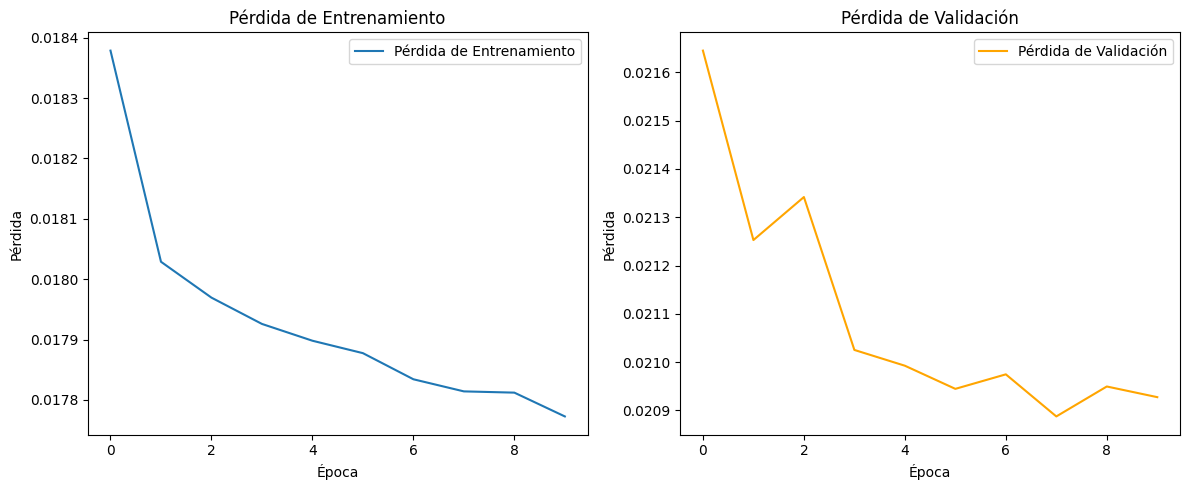

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,1.003062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,92.0,0.0,1.0,0.0,0.0,0.039620,0.0,0.0,0.0,...,1.0,1.024132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.039330,0.0,0.0,0.0,...,1.0,0.990753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.031846,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 91.0, 'actfunct': 'relu', 'dropout': 0.03184592933517118, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_absolute_error', 'batch_size': 46, 'n_neurs_capa_densa': 79, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 91.0, 'actfunct': 'relu', 'dropout

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 91)             │        33,852 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 91)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            92 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,944 (132.59 KB)

 Trainable params: 33,944 (132.59 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1105/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0188
Epoch 1: val_loss improved from inf to 0.02130, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0188 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 2/10
1106/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0181
Epoch 2: val_loss improved from 0.02130 to 0.02129, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0181 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 3/10
1102/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0180
Epoch 3: val_loss improved from 0.02129 to 0.02120, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0180 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 4/10
1107/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0182
Epoch 4: val_loss improved from 0.02120 to 0.02119, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step

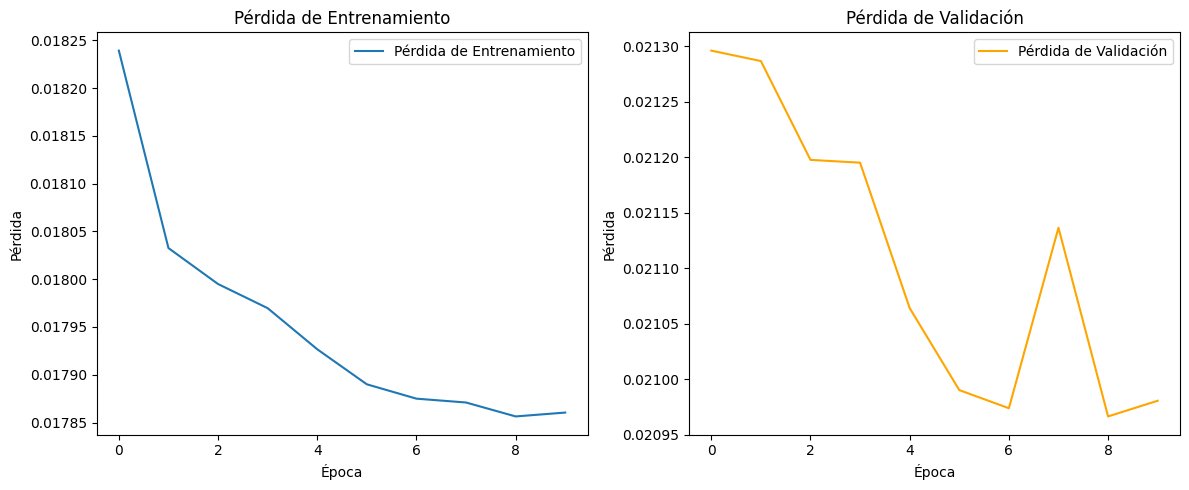

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,1.003062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,92.0,0.0,1.0,0.0,0.0,0.039620,0.0,0.0,0.0,...,1.0,1.024132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.039330,0.0,0.0,0.0,...,1.0,0.990753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.031846,0.0,0.0,0.0,...,1.0,0.995588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


NAME,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_Close,Fibonacci_150_cuerpo,Fibonacci_200_sombra,Media_Movil_250_rendimiento,Suavizamiento_Exponencial_0.3_rendimiento,Media_Movil_3_rendimiento,Suavizamiento_Exponencial_0.6_rendimiento,Suavizamiento_Exponencial_0.5_Close,Fibonacci_50_cuerpo,Suavizamiento_Exponencial_0.05_rendimiento
NEW_VALUE,1.0,90.0,0.0,1.0,0.0,0.0,0.132559,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


all_dict_capas (diccionario con la configuración de cada capa) {'capa_0': {'n_neurs': 90.0, 'actfunct': 'relu', 'dropout': 0.13255888169318342, 'bidirectional': 0.0, 'LSTM_o_GRU': 0.0}}
diccionario con la configuración general de la red {'N_capas': 1, 'cerrar_con_capa_densa': 0, 'optimizador': 'adam', 'loss_function': 'mean_absolute_error', 'batch_size': 46, 'n_neurs_capa_densa': 78, 'actfunct_capa_densa': 'relu'}
inputs considerados en la red ['Media_Movil_4_rendimiento', 'Media_Movil_50_rendimiento', 'Fibonacci_100_sombra', 'Media_Movil_80_rendimiento', 'Media_Movil_250_Close', 'Suavizamiento_Exponencial_0.2_rendimiento', 'Fibonacci_50_sombra', 'Media_Movil_100_Close', 'Fibonacci_80_sombra', 'Media_Movil_80_Close', 'Suavizamiento_Exponencial_0.6_Close', 'Suavizamiento_Exponencial_0.05_Close', 'Suavizamiento_Exponencial_0.3_rendimiento', 'Media_Movil_3_rendimiento', 'Suavizamiento_Exponencial_0.05_rendimiento']
2. Crear red 



{'capa_0': {'n_neurs': 90.0, 'actfunct': 'relu', 'dropout

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 90)             │        33,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,211 (129.73 KB)

 Trainable params: 33,211 (129.73 KB)

 Non-trainable params: 0 (0.00 B)

None
3. Entrenar red 



Epoch 1/10
1103/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0187
Epoch 1: val_loss improved from inf to 0.02133, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0187 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 2/10
1104/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0182
Epoch 2: val_loss did not improve from 0.02133
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0182 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 3/10
1104/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0178
Epoch 3: val_loss did not improve from 0.02133
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0178 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 4/10
1102/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0184
Epoch 4: val_loss improved from 0.02133 to 0.02131, saving model to mejor_modelo.keras
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0184 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 5/10
1103/1108 ━━━━━━

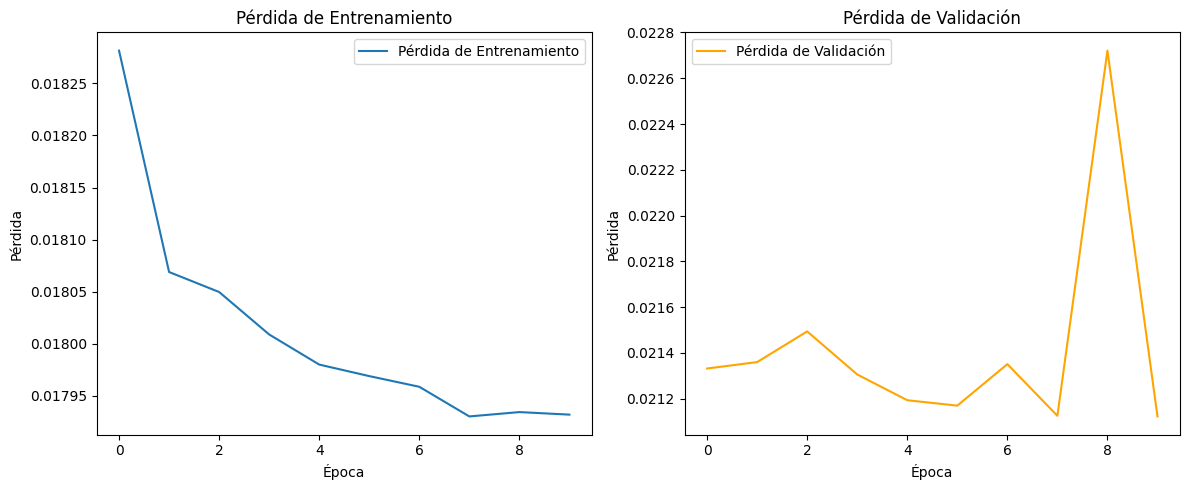

De comprobarse bien, se puede usar BD_RLM y no el new hacia abajo en la función
ejecutar_RLM


,N_capas,n_neurs_capa_0,actfunct_capa_0_tanh,actfunct_capa_0_relu,actfunct_capa_0_sigmoid,actfunct_capa_0_LeakyReLU,dropout_capa_0,bidirectional_capa_0,LSTM_o_GRU_capa_0,cerrar_con_capa_densa,...,Suavizamiento_Exponencial_0.05_rendimiento,ECM_test_norm,n_neurs_capa_1,actfunct_capa_1_tanh,actfunct_capa_1_relu,actfunct_capa_1_sigmoid,actfunct_capa_1_LeakyReLU,dropout_capa_1,bidirectional_capa_1,LSTM_o_GRU_capa_1
0,1.0,120.0,1.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,...,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,2.0,110.0,1.0,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,...,1.0,1.000000,60.0,0.0,0.0,1.0,0.0,0.2,0.0,0.0
NEW_VALUE,1.0,100.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,1.0,1.091930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,98.0,1.0,0.0,0.0,0.0,0.011712,0.0,0.0,0.0,...,1.0,0.964864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,95.0,0.0,1.0,0.0,0.0,0.024732,0.0,0.0,0.0,...,1.0,0.989518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,93.0,0.0,0.0,1.0,0.0,0.042807,0.0,0.0,0.0,...,1.0,1.003062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,92.0,0.0,1.0,0.0,0.0,0.039620,0.0,0.0,0.0,...,1.0,1.024132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.039330,0.0,0.0,0.0,...,1.0,0.990753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,91.0,0.0,1.0,0.0,0.0,0.031846,0.0,0.0,0.0,...,1.0,0.995588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NEW_VALUE,1.0,90.0,0.0,1.0,0.0,0.0,0.132559,0.0,0.0,0.0,...,1.0,1.002519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


N_capas 1


SystemExit: Continuar acá: ver url https://chatgpt.com/c/66f9ed7b-bf70-8000-89b4-e2fe09ce9a9e

In [160]:
# 0. Comenzar con una arquitectura definida

# 0.A: Se lee la BD de RLM
df_arquitectura = df_default.copy()
BD_RLM = pd.DataFrame()
if 'BD_RLM.pkl' in os.listdir(carpeta_LSTM):
    BD_RLM = pickle_act(f'{carpeta_LSTM}BD_RLM', mode = 'open')

for i in range(iteraciones_arquitecturas):
    # 1. Describir la arquitectura definida en la BD arriba para RLM
    
    # 1.A: Seleccionar el último registro como arquitectura
    #df_arquitectura = BD_RLM.tail(1).reset_index(drop = True)
    display(df_arquitectura)
    
    #print('Continuar acá: crear función obtener_base_arquitectura')
    all_dict_capas, dict_general, lista_inputs = obtener_base_arquitectura(df_arquitectura) # Función que obtiene la base de la arquitectura, devuelve el detalle de cada capa en diccionario + otros parametros  # Basicamente, interpreta las dummies y otras cosas
    print('all_dict_capas (diccionario con la configuración de cada capa)', all_dict_capas)
    print('diccionario con la configuración general de la red',  dict_general)
    print('inputs considerados en la red', lista_inputs)

    # 2. Crear la red neuronal a partir de la descripción de la arquitectura
    print('2. Crear red \n\n\n')
    model, set_inputs = crear_LSTM(all_dict_capas, dict_general, lista_inputs) # Función que crea la red neuronal a partir de la descripción de la arquitectura
    # 3. Entrenar la red neuronal (una cantidad definida de epochs)
    print('3. Entrenar red \n\n\n')
    mejor_modelo_test, val_loss_per_epoch = train_LSTM(model, set_inputs, dict_general, df_train, epochs = epochs, graficar = graficar)
    best_val_loss = min(val_loss_per_epoch) # El mejor de la lista que acumula el loss en cada epoch
    
    # 4a. Ocupar el loss de testeo / promedio de loss de testeo para ese tipo de loss (ej: 'loss_function': 'mean_squared_error', es un tipo de loss) registrados en BD_RLM (para "normalizar" por loss). La RLM debe "predecir" este valor
    # 4b. Agregar en BD_RLM los campos test_error y test_error_normalizado (incluido en este subproceso)
    # 4c. Guardar la red neuronal en BD_RLM (no lo veo necesario. Es mejor tener una preselección y, en otro código, entrenar más este conjunto de mejores redes)
    # 4d. Con un learning rate, buscar un nuevo punto y una nueva arquitectura
    
    BD_RLM = update_BD_RLM(BD_RLM, df_arquitectura, best_val_loss, dict_general) # Agrega df arquitectura a BD con valores de ECM y ECM norm    
    df_betas = ejecutar_RLM(BD_RLM) # Se buscan los coeficientes beta (sin intercepto en las primeras iteraciones

    df_arquitectura = generar_nueva_arquitectura(df_arquitectura = df_arquitectura, df_betas = df_betas, learning_rate_RLM = learning_rate_RLM) # Se crea una nueva arquitectura

    # 5. Guardar BD_RLM
    pickle_act(f'{carpeta_LSTM}BD_RLM', BD_RLM, mode = 'save')
    # 6. Si criterio de salida: salir
    
    #BD_RLM = BD_RLM_new.copy()
    #df_arquitectura = df_arquitectura_nueva.copy()
    
    
sys.exit('Continuar acá: ver url https://chatgpt.com/c/66f9ed7b-bf70-8000-89b4-e2fe09ce9a9e')  
# Ver: # Anexo: Predict y medición

# Ancla 4

In [ ]:
sys.exit('ecm coregido debe actualuizarse para toda bd rlm')

In [ ]:
#print('Antes de crear esta función (de arriba), debe ir lo de abajo')
print('Crear primero caso df_default (f: generar_nueva_arquitectura)')
print('Falta crear un lista_input como lista_inputs inicial. De esta forma lista_inputs son todos los permitidos en algún momento, mientras que lista-inputs_inicial, los que están en el df_default (buscar: # Se crea, sin VALUES inicialmente...aqui debe ir con lista_inputs_inicial')
print('Al ejecutar este proceso, un nuevo input en lista input (que no haya sido visto antes, debe ser integrado en la rrnn actual, más todo lo que esa red ya tenía...Por o tanto el default inicial será lista inputs)')
sys.exit('Continuar aqui (250120): Esta función tambien debe reemplazar df_default inicial (si recibe df_arq vacío)')

In [ ]:
sys.exit('Lo de abajo debería ir incluido arriba')

In [180]:
df_k = df_arquitectura.T.rename(columns = {0: 'VALUE'}).reset_index().rename(columns = {'index': 'NAME'})
df_k['BETA'] = betas
#df_k['VALUE'] -= learning_rate_RLM * df_k['BETA']
df_k['CAT'] = df_k['NAME'].apply(categorizar_campo)
df_k['CAT_BASE'] = df_k['CAT'].apply(lambda x: x.split('-')[0])

In [ ]:
df_k = df_k.T

# Dejar la primera fila como los campos
df_k.columns = df_k.iloc[0]
df_k = df_k.iloc[1:]
df_k

In [ ]:
sys.exit('Otros')

In [ ]:
sys.exit('Continuar acá: ver url https://chatgpt.com/c/66f9ed7b-bf70-8000-89b4-e2fe09ce9a9e')

# Anexo: Predict y medición

In [ ]:
display(df_control.head())

# Prueba predict (llevar a función Predict_LSTM)

X_control = df_control[list(set_inputs)].values
Y_control = df_control['Y'].values

loss = mejor_modelo_test.evaluate(X_control, Y_control)
print('Loss en control:', loss)

# Muestra los resultados
predicciones = mejor_modelo_test.predict(X_control)
df_predicciones = df_control.copy()
df_predicciones['PREDICCION'] = predicciones

df_control['PREDICCION'] = predicciones

# Calcula ECM y EAM

df_control['ERROR'] = df_control['Y'] - df_control['PREDICCION']
df_control['ERROR_ABS'] = abs(df_control['ERROR'])
eam = df_control['ERROR_ABS'].mean()

df_control['ERROR_CUAD'] = df_control['ERROR'] ** 2
ecm = df_control['ERROR_CUAD'].mean()

print('ECM:', ecm, 'EAM:', eam)



# KPIs medición

df_errores = pd.DataFrame()
df_kpis = pd.DataFrame()
df_clasificacion_all = pd.DataFrame()

for i in range(len(df_activos)):
    simbolo, nombre = df_activos.loc[i]
    df_control_i = df_control[df_control['VALOR'] == simbolo].reset_index(drop = True)
    df_control_i = df_control_i.merge(df_precios, on = ['VALOR', 'DATE'], how = 'left')
    df_control_i = df_control_i[['VALOR', 'DATE', 'PRECIO', 'Y', 'PREDICCION']]
    df_control_i = df_control_i.sort_values('DATE').reset_index(drop = True)
    precio_base = df_control_i['PRECIO'][0] / (1 + df_control_i['Y'][0])
    
    df_control_i['CLASIFICACION'] = np.where(df_control_i['Y'] >= 0, np.where(df_control_i['PREDICCION'] >= 0, 'TP', 'FN'), np.where(df_control_i['PREDICCION'] >= 0, 'FP', 'TN'))

    df_clasificacion_i = df_control_i[['CLASIFICACION']]
    df_clasificacion_i['CUENTA'] = 1
    df_clasificacion_i = df_clasificacion_i.groupby('CLASIFICACION').sum().reset_index()
    df_clasificacion_i['VALOR'] = simbolo
    df_clasificacion_all = pd.concat([df_clasificacion_all, df_clasificacion_i], axis = 0)
    
    lista_ops = list(df_clasificacion_i['CLASIFICACION'].unique())
    for c in ['FN', 'FP', 'TN', 'TP']:
        if c not in lista_ops:
            df_clasificacion_i = pd.concat([df_clasificacion_i, pd.DataFrame({'CLASIFICACION': [c], 'CUENTA': [0], 'VALOR': [simbolo]})])

    display(df_clasificacion_i)
    
    accuracy = df_clasificacion_i[df_clasificacion_i['CLASIFICACION'].isin(['TP', 'TN'])]['CUENTA'].sum() / df_clasificacion_i['CUENTA'].sum() # True, sobre todos los demás
    precision = df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'TP']['CUENTA'].values[0] / (df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'TP']['CUENTA'].values[0] + df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'FP']['CUENTA'].values[0]) # True, sobre todos los que se predijeron como True
    recall = df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'TP']['CUENTA'].values[0] / (df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'TP']['CUENTA'].values[0] + df_clasificacion_i[df_clasificacion_i['CLASIFICACION'] == 'FN']['CUENTA'].values[0]) # True, sobre todos los que son True

    df_kpis_new = pd.DataFrame({'VALOR': [simbolo], 'ACCURACY': [accuracy], 'PRECISION': [precision], 'RECALL': [recall]})
    df_kpis = pd.concat([df_kpis, df_kpis_new], axis = 0)

    df_control_i['PRECIO_PREDICCION'] = 0
    df_control_i['PRECIO_PREDICCION'][0] = precio_base * (1 + df_control_i['PREDICCION'][0])
    
    for i in range(1, len(df_control_i)):
        df_control_i['PRECIO_PREDICCION'][i] = df_control_i['PRECIO'][i - 1] * (1 + df_control_i['PREDICCION'][i]) 
    #display(df_control_i)
    
    ecm = ((df_control_i['Y'] - df_control_i['PREDICCION']) ** 2).mean()
    eam = abs(df_control_i['Y'] - df_control_i['PREDICCION']).mean()
    n = len(df_control_i)
    
    df_errores_new = pd.DataFrame({'VALOR': [simbolo], 'ECM': [ecm], 'EAM': [eam], 'N': [n]})
    df_errores = pd.concat([df_errores, df_errores_new], axis = 0)
    
    # plotear PRECIO Y PRECIO_PREDICCION

    #df_control_i = df_control_i[df_control_i['DATE'] <= "2020-01-01"]
    plt.figure(figsize = (12, 6))
    plt.plot(df_control_i['DATE'], df_control_i['Y'], label = 'Rendimiento Real')
    plt.plot(df_control_i['DATE'], df_control_i['PREDICCION'], label = 'Rendimiento Predicción')
    plt.title(f'{nombre} - {simbolo}')
    plt.legend()
    plt.show()


display(df_kpis)
display(df_errores)

ecm_tot = (df_errores['ECM'] * df_errores['N']).sum() / df_errores['N'].sum()
eam_tot = (df_errores['EAM'] * df_errores['N']).sum() / df_errores['N'].sum()

print('ecm_tot', ecm_tot, 'eam_tot', eam_tot)

display(df_clasificacion_all)





In [ ]:
# KPIs agregados (para todos  los valores)
df_clasificacion_all_agr = df_clasificacion_all[['CLASIFICACION', 'CUENTA']].groupby('CLASIFICACION').sum().reset_index()

lista_ops = list(df_clasificacion_all_agr['CLASIFICACION'].unique())
for c in ['FN', 'FP', 'TN', 'TP']:
    if c not in lista_ops:
        df_clasificacion_all_agr = pd.concat([df_clasificacion_all_agr, pd.DataFrame({'CLASIFICACION': [c], 'CUENTA': [0], 'VALOR': ['ALL']})])

display(df_clasificacion_all_agr)

accuracy = df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'].isin(['TP', 'TN'])]['CUENTA'].sum() / df_clasificacion_all_agr['CUENTA'].sum() # True, sobre todos los demás
precision = df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'TP']['CUENTA'].values[0] / (df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'TP']['CUENTA'].values[0] + df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'FP']['CUENTA'].values[0]) # True, sobre todos los que se predijeron como True
recall = df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'TP']['CUENTA'].values[0] / (df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'TP']['CUENTA'].values[0] + df_clasificacion_all_agr[df_clasificacion_all_agr['CLASIFICACION'] == 'FN']['CUENTA'].values[0]) # True, sobre todos los que son True

df_kpis_new = pd.DataFrame({'VALOR': ['ALL'], 'ACCURACY': [accuracy], 'PRECISION': [precision], 'RECALL': [recall]})
df_kpis_new

In [ ]:
print('Primero, generar algorítmo macro')
sys.exit()

# Otros

In [ ]:
sys.exit()

### LSTM Básica (Revisar este ejemplo)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Generar datos de ejemplo: secuencia de números
data = np.array([i for i in range(1000)], dtype=float)
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1))

# Definir el tamaño de las secuencias
timesteps = 10
X = []
y = []

for i in range(len(data) - timesteps):
    X.append(data[i:i + timesteps])
    y.append(data[i + timesteps])

X = np.array(X)
y = np.array(y)

# Redimensionar X para que tenga forma (muestras, timesteps, características)
X = np.reshape(X, (X.shape[0], timesteps, 1))

# Crear el modelo LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=False, input_shape=(timesteps, 1)))
model.add(Dense(units=1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X, y, epochs=10, batch_size=32)

# Predecir utilizando el modelo entrenado
predicciones = model.predict(X)

# Invertir la normalización para ver los valores originales de la predicción
# Volver a darle forma para el escalado inverso
predicciones_reshaped = predicciones.reshape(-1, 1)
predicciones_originales = scaler.inverse_transform(predicciones_reshaped)

# Mostrar primeras 5 predicciones desescaladas
print(predicciones_reshaped[:5])


In [ ]:
predicciones.shape, y.shape

In [ ]:
y.min(), y.max()

In [ ]:
# Graficando ambos vectores
plt.figure(figsize=(12, 6))
plt.plot(predicciones, label="Predicciones")
plt.plot(y, label="Y", alpha=0.75)

plt.title("Comparación de Predicciones Originales y Y")
plt.xlabel("Índice")
plt.ylabel("Valores")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
((predicciones_originales - y) ** 2).mean()

In [ ]:
predicciones_originales.shape

In [ ]:
# Caso con retorno
# 
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from sklearn.preprocessing import MinMaxScaler

# Generar datos de ejemplo: secuencia de números
data = np.array([i for i in range(1000)], dtype=float)
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1))

# Definir el tamaño de las secuencias
timesteps = 10
X = []
y = []

for i in range(len(data) - timesteps):
    X.append(data[i:i + timesteps])
    y.append(data[i + 1:i + timesteps + 1])  # Desplazar las etiquetas en 1 paso hacia adelante

X = np.array(X)
y = np.array(y)

# Redimensionar X para que tenga forma (muestras, timesteps, características)
X = np.reshape(X, (X.shape[0], timesteps, 1))
y = np.reshape(y, (y.shape[0], timesteps, 1))  # También se da forma a 'y' para cada paso de tiempo

# Crear el modelo LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(timesteps, 1)))
model.add(TimeDistributed(Dense(units=1)))  # Predicción en cada paso de tiempo

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X, y, epochs=10, batch_size=32)

# Predecir utilizando el modelo entrenado
predicciones = model.predict(X)

# Invertir la normalización para ver los valores originales
predicciones_originales = scaler.inverse_transform(predicciones.reshape(-1, 1)).reshape(predicciones.shape)

# Mostrar primeras 5 secuencias de predicciones
print(predicciones_originales[:5])


# Clase Red Neuronal

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from keras.initializers import RandomUniform

In [ ]:
class Callback(tf.keras.callbacks.Callback): # Esta clase impide que en el entrenamiento de la FFNN, se muestren los resultados de cada epoch (model.fit)
    SHOW_NUMBER = 30
    counter = 0
    epoch = 0

    def on_epoch_begin(self, epoch, logs = None):
        self.epoch = epoch

    def on_train_batch_end(self, batch, logs = None):
        if self.counter == self.SHOW_NUMBER or self.epoch == 1:
            None
            #print('Epoch: ' + str(self.epoch) + ' loss: ' + str(logs['loss']))
            if self.epoch > 1:
                self.counter = 0
        self.counter += 1

In [ ]:
def definir_arquitectura(str_arquitectura): # convierte un str de arquitectura a una matriz de arquitectura
    arquitectura = []
    if str_arquitectura == "0":
        return arquitectura
    
    lista_neuronas = str_arquitectura.split(',')

    for neurona in lista_neuronas:
        arquitectura.append([neurona.split('_')[0], int(neurona.split('_')[1])])
    
    return arquitectura

In [ ]:
def generar_matriz_transformacion(lista_representativa, eliminar):
    # Solo permite eliminar filas y columnas
    vector_rep = np.array(lista_representativa)
    #  T es una mariz de ceros, de dimensiones vector_rep.sum() [cantidad de capos compartidos, interseccion] x len(campos_base_x)
    T = np.zeros((vector_rep.sum(), len(vector_rep)))

    i, j = 0, 0
    for k in range(len(vector_rep)):
        if vector_rep[k] == 1:
            T[i, j] = 1
            i, j = i + 1, j + 1
        else:
            j += 1

    if eliminar == 'columnas': # Se devuelve la matriz transpuesta
        T = T.T
    return T


def generar_matriz_transformacion_estructurada(lista_representativa):
    # Permite agregar filas y columnas random
    
    vector_rep = np.array(lista_representativa)
    T = np.zeros((len(vector_rep), vector_rep.sum()))
    T.shape

    i, j = 0, 0
    for k in range(len(vector_rep)):
        if vector_rep[k] == 1:
            T[i, j] = 1
            i, j = i + 1, j + 1
        else:
            for j2 in range(vector_rep.sum()):
                # agregar un random uniform entre -1 y 1
                T[i, j2] = np.random.uniform(-1, 1)
            i += 1

    return T
    

In [ ]:
def estandarizar(df):
    df_estandarizacion = pd.DataFrame()
    for c in list(set(df.columns) - {'VALOR', 'DATE', 'PREDICT'}):
        promedio, desvest = df[c].mean(), df[c].std()
        df_estandarizacion_new = pd.DataFrame({'CAMPO': [c], 'PROMEDIO': [promedio], 'DESVIACION': [desvest]})
        df_estandarizacion = pd.concat([df_estandarizacion, df_estandarizacion_new])
        df[c] = (df[c] - promedio) / desvest
    return df, df_estandarizacion

def normalizar(df):
    df_normalizacion = pd.DataFrame()
    for c in list(set(df.columns) - {'VALOR', 'DATE', 'PREDICT'}):
        n_min, n_max = df[c].min(), df[c].max()
        df_normalizacion_new = pd.DataFrame({'CAMPO': [c], 'MIN': [n_min], 'MAX': [n_max]})
        df_normalizacion = pd.concat([df_normalizacion, df_normalizacion_new])
        df[c] = (df[c] - n_min) / (n_max - n_min)
    return df, df_normalizacion


In [ ]:
class Red_Neuronal():

    def __init__(self, str_arquitectura, campos_input, cofre, seguimiento, output_level, metrica, df_activos, herencia = False, nombre_clase_heredada = None, cambio = None, dic_cambios = None, campos_input_heredados = None): 
    
        # Se guardan en el init, los atributos iniciales del objeto
        self.str_arquitectura = str_arquitectura # arquitectura asociada a la red neuronal 
        #self.nombre = nombre # nombre de la red neuronal
        self.cofre = f'{cofre}Red_Neuronal/' # donde se guardan y rescatan las redes, con su info actualizada
        self.seguimiento = seguimiento
        self.output_level = output_level
        self.metrica = metrica
        self.raw_x = pd.DataFrame({'DATE': [], 'NAME': []})
        #self.campos_input = campos_input
        #self.campos_output = campos_output
        self.dic_data = {}
        self.best_test_loss = float('inf')
        self.herencia = herencia
        self.nombre_clase_heredada = nombre_clase_heredada
        self.cambio = cambio
        self.dic_cambios = dic_cambios
        self.df_activos = df_activos
        
        #print('Activos seleccionados 0')
        #display(self.df_activos)
        
        self.campos_input_heredados = campos_input_heredados
        #self.campos_input_heredados = campos_input
        #self.epochs = epochs
        
        self.campos_output = f'Y_{self.metrica}_{self.output_level}'
        
        self.inicializar(campos_input, self.campos_output)
        self.modo_arquitectura = self.rescatar() # Rescata el objeto (y toda su información) si existe
        
        #print('Activos seleccionados')
        #display(self.df_activos)
        return None
                
    def rescatar(self):
        if f'{self.nombre}.pkl' not in os.listdir(self.cofre):
            #print('Rescatar')
            self.arquitectura = definir_arquitectura(self.str_arquitectura) # Se define la arquitectura con su nomeclatura
            #print('NAME REV')
            #print(self.str_arquitectura, self.arquitectura)
            
            if self.herencia: # Si se puede, se rescatan los datos del objeto heredado
                print('SI HERENCIA FFNN')
                valor_cargado_heredado = pickle_act(f'{self.cofre}{self.nombre_clase_heredada}') # De lo contrario, se lee el objeto guardado y se rescatan sus atributos
                for key, value in vars(valor_cargado_heredado).items(): # vars contiene los atributo y sus valores como diccionario (str, obj) vars = {'x': valor de x, 'y': valor de y}
                    if key in ['herencia', 'nombre_clase_heredada', 'cambio', 'dic_cambios', 'str_arquitectura', 'cofre', 'seguimiento', 'output_level', 'arquitectura', 'campos_input', 'campos_input_heredados', 'df_activos']: # atributos no heredados
                        continue
                    elif key == 'model':
                        setattr(self, 'model_base', value) # Aquí, model se renombra como model base
                    #elif key == 'campos_input':
                    #    setattr(self, 'campos_input_heredados', value)
                    # si se heredan! dic_data, model 
                    setattr(self, key, value) # setattr(objeto, atributo, valor) -> objeto.atributo = valor, actúa sobre la clase self, recibe un key (str) y un value (obj) y los asigna a la clase como atributos: self.key = value...es similar a usar un globals(), pero en una clase
                #print('NAME REV2')
                #print(self.str_arquitectura, self.arquitectura)
                
                self.cambiar_ffnn() # El cambio solo existe si hay una herencia, y la nueva red no existe
            else:    
                self.crear_ffnn() # Crea la estructura inicial de la red
            return 'nueva' # Si no se encuentra, no se pueden rescatar los atributos
        
        #print('RESCATE!!')
        valor_cargado = pickle_act(f'{self.cofre}{self.nombre}') # De lo contrario, se lee el objeto guardado y se rescatan sus atributos (todos)
        for key, value in vars(valor_cargado).items(): # vars contiene los atributo y sus valores como diccionario (str, obj) vars = {'x': valor de x, 'y': valor de y}
            if key in ['df_activos']: # atributos no heredados
                continue
            setattr(self, key, value) # setattr(objeto, atributo, valor) -> objeto.atributo = valor, actúa sobre la clase self, recibe un key (str) y un value (obj) y los asigna a la clase como atributos: self.key = value...es similar a usar un globals(), pero en una clase
        return 'rescate'
    
    
    def guardar(self):
        pickle_act(f'{self.cofre}{self.nombre}', variable = self, mode = 'save')
        return None
    
    def crear_ffnn(self, loss = 'mean_squared_error', optimizer = 'adam', metrics = ['accuracy']):
        
        dic_metricas = {'Rendimiento': None, 'Varianza': 'relu'}
        # Inicializador con valores entre 0 y 1
        initializador = RandomUniform(minval = 0, maxval = 1)
    
        # Crea un modelo secuencial
        self.model = keras.Sequential()
        
        if len(self.arquitectura) == 0: # Sin hidden layers
            self.model.add(layers.Dense(self.output_dim, activation = None, input_shape = (self.input_dim,)))

        else:
            for i, layer in enumerate(self.arquitectura):
                #print('NUEVA CAPA', i, layer)
                if i == 0:
                    self.model.add(layers.Dense(layer[1], activation = layer[0], input_shape = (self.input_dim,), kernel_initializer = initializador)) # Capa de entrada
                else:
                    self.model.add(layers.Dense(layer[1], activation = layer[0], kernel_initializer = initializador)) # Cualquier otra capa
            
        # Agrega la capa de salida, con y_test.shape[1] neuronas y sin activación (para que quede libre, y no restringir el número a un no negativo (por ejemplo)
        self.model.add(layers.Dense(1, activation = dic_metricas[self.metrica])) # Rend puede ser negativo, Var no
        
        # Compliación y definición
        self.model.compile(loss = loss, optimizer = optimizer, metrics = metrics)
        
        #print('OK estructura FFNN creada')
        
        """
        for i in range(len(self.arquitectura) + 1):
            weights0_origen, biases0_origen = self.model.layers[i].get_weights()
            print('Capa estr', i)
            print('W estr', weights0_origen.shape)
            print('b estr', biases0_origen.shape)
            print(weights0_origen)
            print(biases0_origen)
        """

        #print('\n\n\n')
        return None 
    
    # cambiar_ffnn(self, cambio, capa_seleccionada, delta_n_neurs_new)
    def cambiar_ffnn(self):
        # Aqui los cambios
        #print('CAMBIAR FFNN')
        #print(self.cambio)
        
        #print('NAME REV3')
        #print(self.str_arquitectura, self.arquitectura)
        
        # 1.3 Agregar neuronas
        if self.cambio == '1_agregar_neuronas':
            
            #print('CREAR', self.arquitectura)
            self.crear_ffnn()
            
            capa_seleccionada = self.dic_cambios['capa_seleccionada']
            delta_n_neurs_new = self.dic_cambios['delta_n_neurs_new']
            #### 1.3.1 matriz anterior
            weights0_origen, biases0_origen = self.model_base.layers[capa_seleccionada].get_weights()
            #weights0_origen.shape, biases0_origen.shape

            # a weights0_origen, se le hace un hstack random
            filas_add, cols_add = weights0_origen.shape[0], delta_n_neurs_new
            A = np.random.rand(filas_add, cols_add)
            weights0_nuevo = np.hstack([weights0_origen, A]) # Se añaden las columnas nuevas

            # a biases0_origen, se le hace un hstack random
            A = np.random.rand(cols_add)
            biases0_nuevo = np.hstack([biases0_origen, A])

            self.model.layers[capa_seleccionada].set_weights([weights0_nuevo, biases0_nuevo]) # Los setea en la red neuronal"""

            #### 1.3.2 matriz siguiente
            weights1_origen, biases1_origen = self.model_base.layers[capa_seleccionada + 1].get_weights()
            weights1_origen.shape, biases1_origen.shape

            # a weights0_origen, se le hace un vstack random
            filas_add, cols_add = delta_n_neurs_new, weights1_origen.shape[1]
            A = np.random.rand(filas_add, cols_add)
            weights1_nuevo = np.vstack([weights1_origen, A]) # Se añaden las columnas nuevas

            self.model.layers[capa_seleccionada + 1].set_weights([weights1_nuevo, biases1_origen]) # Los setea en la red neuronal"""
            
            #print('Nueva estructura ajustada')
        
        elif self.cambio == '2_eliminar_neuronas':
                        
            self.crear_ffnn()
            
            capa_seleccionada = self.dic_cambios['capa_seleccionada'] 
            delta_n_neurs_new = self.dic_cambios['delta_n_neurs_new']
            dic_betas = self.dic_cambios['dic_betas']

            lista_betas_seleccion = dic_betas[capa_seleccionada] # errores imputados a las neuronas en las capas
            
            #print('dic betas', dic_betas)
            df_betas_seleccion = pd.DataFrame(lista_betas_seleccion, columns = ['BETA']) # Se seleccionan las neuronas que serán eliminadas
            df_betas_seleccion['NEURONA'] = df_betas_seleccion.index
            df_betas_seleccion['BETA_ABS'] = np.abs(df_betas_seleccion['BETA'])
            df_betas_seleccion = df_betas_seleccion.sort_values('BETA_ABS', ascending = False).reset_index(drop = True) # Se eligen las neuronas con betas más altos en valr abs
            n_neurs_a_eliminar = abs(self.dic_cambios['delta_n_neurs_new'])

            df_betas_seleccion = df_betas_seleccion.head(n_neurs_a_eliminar)
            neurs_a_eliminar = list(df_betas_seleccion['NEURONA'].unique())
            neurs_a_eliminar.sort()

            lista_representativa = [] # Lista representativa: 0 si es una neurona a eliminar y 1 si es una neurona a conservar
            for i in range(len(lista_betas_seleccion)):
                if i in neurs_a_eliminar:
                    lista_representativa.append(0)
                else:
                    lista_representativa.append(1)

            Ty = generar_matriz_transformacion(lista_representativa, eliminar = 'columnas') # matriz de transformación para eliminar columnas
            Tx = generar_matriz_transformacion(lista_representativa, eliminar = 'filas') 

            #### 1.3.1 matriz anterior (eliminar columnas)
            weights0_origen, biases0_origen = self.model_base.layers[capa_seleccionada].get_weights()  # cambiar por self.model.layers[capa_seleccionada].get_weights()

            weights0_nuevo = weights0_origen @ Ty # cambios en W (se eliminan cols, transformando por derecha)
            biases0_nuevo = Tx @ biases0_origen # cambios en b (se eliminan filas, transformando por izquierda)
            self.model.layers[capa_seleccionada].set_weights([weights0_nuevo, biases0_nuevo]) # seteo de las nuevas configuraciones

            #### 1.3.2 matriz siguiente
            weights1_origen, biases1_origen = self.model_base.layers[capa_seleccionada + 1].get_weights()

            weights1_nuevo = Tx @ weights1_origen # cambios en W (se eliminan filas, transformando por izquierda)
            # biases1_origen se mantiene
            self.model.layers[capa_seleccionada + 1].set_weights([weights1_nuevo, biases1_origen]) # seteo de las nuevas configuraciones
            
        elif self.cambio == '3_eliminar_capa': # ver hojas 16 & 17

            self.crear_ffnn()
            
            capa_seleccionada = self.dic_cambios['capa_seleccionada'] # cambiar por self.dic_cambios
            delta_n_neurs_new = self.dic_cambios['delta_n_neurs_new']
            
            for i in range(len(self.arquitectura) + 2): # +1 por capa de salida + 1 por capa de arquitectura original
                weights0_origen, biases0_origen = self.model_base.layers[i].get_weights()
                if i < capa_seleccionada:
                    self.model.layers[i].set_weights([weights0_origen, biases0_origen]) # se mantiene
                elif (i == capa_seleccionada) or (i == capa_seleccionada + 1): # se conserva el random generado (se pierde la matriz antecesora y sucesora de la capa)
                    None
                else:
                    self.model.layers[i - 1].set_weights([weights0_origen, biases0_origen]) # se mantiene
        
        elif self.cambio == '3_agregar_capa': # Ver hojas 17 & 18
            self.crear_ffnn()
            #{'capa_seleccionada': 3, 'neuronas_seleccionadas': 4, 'funcion_seleccionada': 'relu'}
            capa_seleccionada = self.dic_cambios['capa_seleccionada']
            for i in range(len(self.arquitectura) + 1): # +1 por capa de salida 
                if i < capa_seleccionada:
                    weights0_origen, biases0_origen = self.model_base.layers[i].get_weights() # se obtienen los W-b de la red heredada
                    self.model.layers[i].set_weights([weights0_origen, biases0_origen]) # se reemplazan en la nueva red directamente
                elif (i == capa_seleccionada) or (i == capa_seleccionada + 1): # se conserva el random generado (se pierde la matriz antecesora y sucesora de la capa)
                    None
                else:
                    weights0_origen, biases0_origen = self.model_base.layers[i - 1].get_weights()
                    self.model.layers[i].set_weights([weights0_origen, biases0_origen])
        
        elif (self.cambio == '4_cambio_funcion') or (self.cambio == '5_cambio_funcion'):
            
            self.crear_ffnn() # Se crea la nueva estructura con la nueva función de activación
            
            for i in range(len(self.arquitectura) + 1): # +1 por capa de salida 
                weights0_origen, biases0_origen = self.model_base.layers[i].get_weights() # se obtienen los W-b de la red heredada
                self.model.layers[i].set_weights([weights0_origen, biases0_origen]) # se reemplazan en la nueva red directamente
        
        elif self.cambio == '6_cambios_inputs_agregar':
            
            # AGREGAR!!!
            self.input_dim, self.output_dim = len(self.campos_input), len(self.campos_output)
            self.crear_ffnn() # Se crea la nueva estructura
                        
            lista_representativa = [] # Lista representativa: 0 si es una neurona nueva (se generará un random en la función generar_matriz_transformacion_estructurada) y 1 si es una neurona a conservar
            for elemento in self.campos_input:
                if elemento in self.campos_input_heredados:
                    lista_representativa.append(1)
                else:
                    lista_representativa.append(0)

            Tx = generar_matriz_transformacion_estructurada(lista_representativa)
            
            # Cambio en las matrices de input
            for i in range(len(self.arquitectura) + 1):
                weights, biases = self.model_base.layers[i].get_weights() # se obtienen los W-b de la red heredada
                if i == 0:
                    weights = Tx @ weights # cambios en W (se eliminan filas, transformando por izquierda)
                self.model.layers[i].set_weights([weights, biases]) # se reemplazan en la nueva red directamente
            
                
        elif self.cambio == '7_cambios_inputs_eliminar':
            
            self.input_dim, self.output_dim = len(self.campos_input), len(self.campos_output)
            self.crear_ffnn() # Se crea la nueva estructura
            
            lista_representativa = [] # Lista representativa: 0 si es ya no existe y 1 si es una neurona a conservar
            for elemento in self.campos_input_heredados:
                if elemento in self.campos_input:
                    lista_representativa.append(1)
                else:
                    lista_representativa.append(0)
            
            Tx = generar_matriz_transformacion(lista_representativa, 'filas')
            
            # Cambio en las matrices de input
            for i in range(len(self.arquitectura) + 1):
                weights, biases = self.model_base.layers[i].get_weights() # se obtienen los W-b de la red heredada
                if i == 0:
                    weights = Tx @ weights # cambios en W (se eliminan filas, transformando por izquierda)
                self.model.layers[i].set_weights([weights, biases]) # se reemplazan en la nueva red directamente

        return None
                
    def inicializar(self, campos_input, campos_output): # Si la red no fue rescatada, entonces se leen algunos parámetros
        #print('Inicializar')
        
        #print('campos_input', campos_input)
        # Estandarización de campos input y output
        if campos_input == None:
            self.campos_inputs_default() # Se generan los campos  inputs por  default: Todos los existentes en los valores que están en df_activos
        elif type(campos_input) == str:
            self.campos_input = campos_input.split(',')
        else:
            self.campos_input = campos_input
        self.campos_input.sort()
        
        self.campos_output = campos_output.split(',')
        self.campos_output.sort()
        
        self.str_campos_input, self.str_campos_output = ','.join(self.campos_input),  ','.join(self.campos_output)
        self.input_dim, self.output_dim = len(self.campos_input), len(self.campos_output)
        
        #print(self.campos_input, self.campos_output)
        #print('dims', self.input_dim, self.output_dim)
        
        # Reconoce si existe, o crea un id nuevo
        if 'df_info_ffnn.pkl' not in os.listdir(self.seguimiento):
            self.df_info_ffnn = pd.DataFrame(columns = ['str_arquitectura', 'campos_input', 'campos_output', 'nombre'])
            #return None
        else:
            self.df_info_ffnn = pickle_act(f'{self.seguimiento}df_info_ffnn') # Se lee si existe
            
        # Asignación de nombre...se rescata si existe, de lo contrario se asigna uno nuevo
        df_info_ffnn_filtrado = self.df_info_ffnn[(self.df_info_ffnn['str_arquitectura'] == self.str_arquitectura) & (self.df_info_ffnn['campos_input'] == self.str_campos_input) & (self.df_info_ffnn['campos_output'] == self.str_campos_output)].reset_index(drop = True) 
        
        if len(df_info_ffnn_filtrado) == 0: # asignación de nombre
            self.nombre = 'FFNN_'+ str(len(self.df_info_ffnn) + 1) # Se asigna un nombre con un id
            # Actualización de df info y guardado
            new_row = pd.DataFrame({'str_arquitectura': [self.str_arquitectura], 'campos_input': [self.str_campos_input], 'campos_output': [self.str_campos_output], 'nombre': [self.nombre]})
            self.df_info_ffnn = pd.concat([self.df_info_ffnn, new_row], axis = 0).reset_index(drop = True)
            pickle_act(f'{self.seguimiento}df_info_ffnn', variable = self.df_info_ffnn, mode = 'save') # Se guarda, solo si se agrega un caso nuevo
        else:
            self.nombre = df_info_ffnn_filtrado['nombre'][0]

        return None
    
    
    def campos_inputs_default(self):
        
        #print('campos_inputs_default')
        cofre0 = '/'.join(self.cofre.split('/')[:-2]) + '/'
        set_campos_inputs = set()
        for i in range(len(self.df_activos)):
            simbolo, nombre = self.df_activos.loc[i]
            # Si no existe el objeto, se crea
            valor = Valor(simbolo, nombre, cofre0) # 
            if len(valor.raw_x) == 0: # No hay datos que aportar
                continue
            set_campos_inputs_new = set([campo for campo in valor.raw_x['NAME'].unique() if campo[:2] != "Y_"])
            #print('set_campos_inputs_new')
            #print(set_campos_inputs_new)
            set_campos_inputs = set_campos_inputs.union(set_campos_inputs_new)
        self.campos_input = list(set_campos_inputs)
        
        #self.campos_input = self.campos_input[:10] # fijado: cambiar!!
        
        return None
    
    def construir_matrices(self):
        
        while True:
        
            # Matrices de input y de output
            #print('Campos inputs en construir matrices')
            #print(self.campos_input)
            #print(self.campos_output)
            # output_level = 10 # 10 días para este ejemplo (esta red neuronal concretamente)
            cofre0 = '/'.join(self.cofre.split('/')[:-2]) + '/'
            df_raw_info = pd.DataFrame()
            for i in range(len(self.df_activos)):
                simbolo, nombre = self.df_activos.loc[i]
                valor = Valor(simbolo, nombre, cofre0) # Si no existe el objeto, se crea 
                if len(valor.raw_x) == 0: # No hay datos que aportar
                    continue
                #print(simbolo, nombre, len(valor.raw_x))
                new_raw_x = valor.raw_x.copy()
                new_raw_x['VALOR'] = simbolo
                
                print('SIMBOLO', simbolo, new_raw_x['DATE'].min(), new_raw_x['DATE'].max())
                df_raw_info = pd.concat([df_raw_info, new_raw_x], axis = 0)
            

            #display(df_raw_info[df_raw_info['X'].isna()])
            #sys.exit('df raw info nan')
            df_raw_info = df_raw_info[['VALOR', 'DATE', 'NAME', 'X']]
            #df_raw_info.head()
            
            #print('Name en raw info')
            #print(df_raw_info['NAME'].unique())
            df_raw_info = df_raw_info[(df_raw_info['NAME'].isin(self.campos_input)) | (df_raw_info['NAME'].str[:2] == 'Y_')] # Se seleccionan solo los campos de input que están declarados en campos input
            #sys.exit('Revisar esto (deberian seleccionarse solo los campos inputs)!')

            # Primero, se separan los inputs de los outputs
            df_raw_info['NATURALEZA'] = np.where(df_raw_info['NAME'].str[:2] == 'Y_', 'Y', 'X')
            df_raw_y = df_raw_info[df_raw_info['NATURALEZA'] == 'Y'].reset_index(drop = True)
            df_raw_x = df_raw_info[df_raw_info['NATURALEZA'] == 'X'].reset_index(drop = True)

            df_X = df_raw_x.pivot_table(index = ['VALOR', 'DATE'], columns = 'NAME', values = 'X').reset_index()
            df_Y = df_raw_y.pivot_table(index = ['VALOR', 'DATE'], columns = 'NAME', values = 'X').reset_index()

            df = df_X.merge(df_Y, on = ['VALOR', 'DATE'], how = 'outer')
        
        #df.to_csv(f'dfX_{self.nombre}.csv', index = False, decimal = ',', sep = ';')
        #sys.exit('dfX.csv')
        
            aprobado = True
            for c in list(set(df.columns) - {'DATE', 'VALOR'}):
                if len(df[df[c].isna()]) > 0:
                    aprobado = False
                    print(f'El campo {c} tiene valores nulos')
                    display(df[df[c].isna()])
                    sys.exit('Salida por campos nulos')
            if aprobado:
                break
            print('B. Espera de completitud de valores en Valor.py: Espera de 30s.')
            time.sleep(30)
        
        """
        for c in list(set(df.columns) - {'DATE', 'VALOR'}):
            if len(df[df[c].isna()]) > 0:
                print(c)
                display(df[df[c].isna()])
                sys.exit('Error en campo')
        """

        # Limpieza de df
        self.lista_campos_output = list(set(df_Y.columns) - {'DATE', 'VALOR'})
        set_delta_dates = set()
        for c in self.lista_campos_output:

            delta = c.split('_')[-1]
            set_delta_dates.add(delta)
        #lista_delta_dates = list(set_delta_dates)
        
        df['PREDICT'] = np.where((df[f'Y_Rendimiento_{delta}'] == 0) & (df[f'Y_Varianza_{delta}'] == 0), True, False)
        #print('lista_delta_dates', lista_delta_dates)
        df, self.df_normalizacion = normalizar(df)

        #df.to_csv(f'dfX_v2_{self.nombre}.csv', index = False, decimal = ',', sep = ';')
        
        #print('La idea es normalizar esta BD')
        #sys.exit(f'Salida para revisión de dfX_v2_{self.nombre}.csv')
        
        delta = self.output_level

        print(f'Y_Rendimiento_{delta}', f'Y_Varianza_{delta}')            
        self.df_predict = df[df['PREDICT']].reset_index(drop = True) # Se aislan los datos para después hacer el predict
        self.df_predict = self.df_predict.drop(columns = ['PREDICT'])
        if len(self.df_predict) == 0:
            sys.exit('Predict sin datos')
        else:
            None
            #print(self.nombre)
            #print(self.df_predict)
        df = df[~df['PREDICT']].reset_index(drop = True) # Se excluyen los casos en los que la varianza y el rend de un día, son 0, para el mismo delta
        df = df.drop(columns = ['PREDICT'])
    
        
        """
        for delta in lista_delta_dates:
            print(f'Y_Rendimiento_{delta}', f'Y_Varianza_{delta}')            
            self.df_predict = df[((df[f'Y_Rendimiento_{delta}'] == 0) & (df[f'Y_Varianza_{delta}'] == 0))].reset_index(drop = True) # Se aislan los datos para después hacer el predict
            if len(self.df_predict) == 0:
                sys.exit('Predict sin datos')
            else:
                print(self.nombre)
                print(self.df_predict)
            df = df[~((df[f'Y_Rendimiento_{delta}'] == 0) & (df[f'Y_Varianza_{delta}'] == 0))].reset_index(drop = True) # Se excluyen los casos en los que la varianza y el rend de un día, son 0, para el mismo delta
        """
        
        if self.output_level not in self.dic_data:
            self.dic_data[self.output_level] = df
        
        return None
    
    def split_data(self, test_size = 0.2): # Como método propio, para poder generar sampleos aleatorios libremente
        
        df = self.dic_data[self.output_level].copy()
        df = df.fillna(0) # Provisorio, para activos que están incompletos con sus datos históricos
        df = df.drop(columns = ['DATE', 'VALOR'])
        Y = df[f'Y_{self.metrica}_{self.output_level}'] # Una sola métrica de output ya que si es varianza,hay que asegurar que sea >= 0
        X = df.drop(columns = self.lista_campos_output)
        x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = test_size) # Split aleatorio de los datos
        x_train, x_test, y_train, y_test = x_train.values, x_test.values, y_train.values, y_test.values # dt to matriz numpy
        return x_train, x_test, y_train, y_test
    
    def matrices_predict(self): # nuevo 240614
        df_x_predict = self.df_predict.drop(columns = self.lista_campos_output) 
        df_x_predict_values = df_x_predict.drop(columns = ['DATE', 'VALOR'])
        x_predict = df_x_predict_values.values
        return df_x_predict, x_predict
    
    def predict_model(self, x_predict):
        y_predict = self.model.predict(x_predict)
        return y_predict
    
    def train_model(self, x_train, x_test, y_train, y_test, batch_size = 32, epochs = 5, n_min = 200, plotear = False): # n_min: cuantos epochs sin superar el best son necesarios para stop
        
        #print('EN TRAIN MODEL\n\n\n\n\n')
        if not plotear:
            e, k = 0, 0
            while True:
                #print('K', k)

                self.model.fit(x_train, y_train, epochs = 1, batch_size = batch_size, validation_data = (x_test, y_test), callbacks = [Callback()], verbose = 0) # Entrenamiento del modelo
                # batch_size: cuantos datos juntos se entrenan a la vez, antes de actualizar los parámetros
                # verbose = 0: muestra menos información de output
                # self.train_loss, self.train_accuracy = self.model.evaluate(x_train, y_train) # Evaluación de test y obtención de performance de testeo
                #print('W-b en train')
                [w, b] = self.model.layers[0].get_weights()
                #print(w)
                #print(b)
                self.test_loss, self.test_accuracy = self.model.evaluate(x_test, y_test) # Evaluación de test y obtención de performance de testeo
                #print(\test_loss, test_accuracy\, self.test_loss, self.test_accuracy)
                if self.test_loss < self.best_test_loss: # Se guardan los mejores registros y el mejor modelo para la predicción (si es que los parámetros mejoran)
                    self.best_test_loss = self.test_loss
                    self.best_test_accuracy = self.test_accuracy
                    self.best_model = self.model
                    k = 0 # reset
                k += 1 # contador de cuantos epochs van sin mejorar el best loss
                if k >= n_min: # criterio de salida
                    break
                
            return None
        
        # plotear = True
        df_plot = pd.DataFrame()
        for e in range(epochs):
            print('epoch', e)
            self.model.fit(x_train, y_train, epochs = 1, batch_size = batch_size, validation_data = (x_test, y_test), verbose = 0)
            
            [w, b] = self.model.layers[0].get_weights()
            #print('W-b en train')
            #print(w)
            #print(b)
            train_loss, train_accuracy = self.model.evaluate(x_train, y_train) # Evaluación de test y obtención de performance de testeo
            test_loss, test_accuracy = self.model.evaluate(x_test, y_test) # Evaluación de test y obtención de performance de testeo
            new_df = pd.DataFrame({'EPOCH': [e], 'TRAIN_LOSS': [train_loss], 'TRAIN_ACCURACY': [train_accuracy], 'TEST_LOSS': [test_loss], 'TEST_ACCURACY': [test_accuracy]})
            display(new_df)
            df_plot = pd.concat([df_plot, new_df], axis = 0)
        
        # plotea
        fig, ax = plt.subplots(1, 2, figsize = (15, 5))
        ax[0].plot(df_plot['EPOCH'], df_plot['TRAIN_LOSS'], label = 'TRAIN LOSS')
        ax[0].plot(df_plot['EPOCH'], df_plot['TEST_LOSS'], label = 'TEST LOSS')
        ax[0].legend()
        ax[0].set_title('LOSS')
        
        ax[1].plot(df_plot['EPOCH'], df_plot['TRAIN_ACCURACY'], label = 'TRAIN ACCURACY')
        ax[1].plot(df_plot['EPOCH'], df_plot['TEST_ACCURACY'], label = 'TEST ACCURACY')
        ax[1].legend()
        ax[1].set_title('ACCURACY')
        plt.show()
        
        self.df_plot = df_plot.copy()
        
        return None
        
        # plotear = True
        df_plot = pd.DataFrame()
        for e in range(epochs):
            self.model.fit(x_train, y_train, epochs = 1, batch_size = batch_size, validation_data = (x_test, y_test), verbose = 0)
            train_loss, train_accuracy = self.model.evaluate(x_train, y_train) # Evaluación de test y obtención de performance de testeo
            test_loss, test_accuracy = self.model.evaluate(x_test, y_test) # Evaluación de test y obtención de performance de testeo
            new_df = pd.DataFrame({'EPOCH': [e], 'TRAIN_LOSS': [train_loss], 'TRAIN_ACCURACY': [train_accuracy], 'TEST_LOSS': [test_loss], 'TEST_ACCURACY': [test_accuracy]})
            df_plot = pd.concat([df_plot, new_df], axis = 0)
        
        # plotea
        fig, ax = plt.subplots(1, 2, figsize = (15, 5))
        ax[0].plot(df_plot['EPOCH'], df_plot['TRAIN_LOSS'], label = 'TRAIN LOSS')
        ax[0].plot(df_plot['EPOCH'], df_plot['TEST_LOSS'], label = 'TEST LOSS')
        ax[0].legend()
        ax[0].set_title('LOSS')
        
        ax[1].plot(df_plot['EPOCH'], df_plot['TRAIN_ACCURACY'], label = 'TRAIN ACCURACY')
        ax[1].plot(df_plot['EPOCH'], df_plot['TEST_ACCURACY'], label = 'TEST ACCURACY')
        ax[1].legend()
        ax[1].set_title('ACCURACY')
        plt.show()
        
        self.df_plot = df_plot.copy()
        
        return None
    
    def error_imputado_neuronas(self, x_train, y_train):
        dic_metricas = {'Rendimiento': None, 'Varianza': 'relu'}
        dic_funciones = {'sigmoid': lambda x: 1 / (1 + np.exp(-x)), None: lambda x: x, 'relu': lambda x: np.maximum(0, x), 'tanh': lambda x: np.tanh(x)}
        dic_derivadas = {'sigmoid': lambda x: x * (1 - x), None: lambda x: 1, 'relu': lambda x: 1 if x > 0 else 0, 'tanh': lambda x: 1 - x ** 2}

        # Algoritmo de obtención de datos
        
        #print(self.model.layers)
        #print(self.arquitectura)
        #for i in range(len(self.model.layers)):
        #    [w, b] = self.model.layers[i].get_weights()
        #    print(i, w.shape, b.shape)
        #sys.exit('Revisar 240524')

        dic_ecuaciones = {}

        # 0. Inicio
        x = x_train
        
        for capa, detalle in enumerate(self.arquitectura):
            [act_fun, n_neurs] = detalle
            #print(capa, act_fun, n_neurs)
            # self.model.layers[capa].get_weights()
            [w, b] = self.model.layers[capa].get_weights()
            if np.isnan(w[0][0]):
                sys.exit('W vacío')
            z = x @ w + b 
            a = dic_funciones[act_fun](z)
                        
            dic_ecuaciones[capa] = {'z': z, 'a': a, 'x': x, 'w': w, 'b': b, 'act_fun': act_fun}
            x = a
            

        # Capa salida
        capa, act_fun, n_neurs = capa + 1, dic_metricas[self.metrica], 1
        #print(capa, act_fun, n_neurs)
        [w, b] = self.model.layers[capa].get_weights()
        z = x @ w + b 
        a = dic_funciones[act_fun](z)
        dic_ecuaciones[capa] = {'z': z, 'a': a, 'x': x, 'w': w, 'b': b, 'act_fun': act_fun}

        # 1. Obtener responsabilidad de cada neurona
        dic_deltas = {}
        # 1.1 Para la ultima capa
        # dL = (a - y) * f'(z)

        a = dic_ecuaciones[capa]['a']
        z = dic_ecuaciones[capa]['z']
        y = y_train.reshape(-1, 1)
        
        derivada = np.vectorize(dic_derivadas[act_fun])(z)
        dL = (a - y) * derivada
        dic_deltas[capa] = dL

        # Para cualquier capa intermedia
        # dL = (dL @ w.T) * f'(z)

        while True:
            w = dic_ecuaciones[capa]['w']
            if capa > 0:
                act_fun_prev = dic_ecuaciones[capa - 1]['act_fun']
                z_prev = dic_ecuaciones[capa - 1]['z']
                a_prev = dic_ecuaciones[capa - 1]['a']
            dL_next = dic_deltas[capa]

            if capa == 0:
                derivada_prev = 1
            elif act_fun_prev == 'relu': # La derivada se aplica a x, y no a f(x)
                derivada_prev = np.vectorize(dic_derivadas[act_fun_prev])(z_prev)
            else:
                derivada_prev = np.vectorize(dic_derivadas[act_fun_prev])(a_prev) # ya que a = f(z) y las derivadas de sigm y tanh están definidas en función de f(z)

            dL = (dL_next @ w.T) * derivada_prev
            capa -= 1
            dic_deltas[capa] = dL
            
            #print('Capa y dL', capa, dL)
            
            if capa == -1: # capa 0 es la primera capa oculta
            #if capa == 0: # capa 0 es la primera capa oculta
                break

        # betas
        self.dic_betas = {}
        for capa in dic_deltas:
            beta = dic_deltas[capa].sum(axis = 0)
            self.dic_betas[capa] = beta
            #print(capa, beta)
        
        return None
    
    #print('C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Markowitz\0. Markowitz FFNN 240322 V1_traspaso a ALginvesting.ipynb')
    

# Clase Búsqueda Inteligente

In [ ]:
def agregar_o_eliminar_inputs(campos_inputs, all_campos_inputs, modo, beta_inputs = []):
    print('campos_inputs', len(campos_inputs), modo)
    print(campos_inputs)
    
    dic_cambios = {}
    if modo == 'agregar':
        delta_opciones = all_campos_inputs - set(campos_inputs)
        delta_agr = len(delta_opciones)
        if delta_agr == 0:
            print('No se pueden agregar más campos')
            dic_cambios['continuar'] = False

        else:
            # elegir random entre 1 y delta_agr
            delta_agr_new = np.random.choice(range(1, delta_agr + 1), p = obtener_lista_probs(delta_agr))
            # elegir delta_agr_new campos random de delta_opciones
            campos_inputs_new = list(np.random.choice(list(delta_opciones), delta_agr_new, replace = False))
            
            print('\n\n\ndelta new', delta_agr_new)
            dic_cambios['continuar'] = True
            campos_inputs += campos_inputs_new
            dic_cambios['campos_inputs_new'] = campos_inputs
            
    else: # modo "eliminar"
        delta_eliminar = len(campos_inputs) - 1 # tiene que quedar al menos un campo de input
        if delta_eliminar == 0:
            print('No se pueden eliminar más campos')
            dic_cambios['continuar'] = False
        
        else:
            delta_eliminar_new = np.random.choice(range(1, delta_eliminar + 1), p = obtener_lista_probs(delta_eliminar))
            #campos_a_eliminar = list(np.random.choice(campos_inputs, delta_eliminar_new, replace = False))
            
            print('\n\n\ndelta_eliminar_new', delta_eliminar_new)
            if len(beta_inputs) == 0: # caso random, en caso de que no exista entrenamiento
                # crea una lista random uniforme (0,1) de tamaño len(campos_inputs)
                beta_inputs = np.random.rand(len(campos_inputs))

            #print('beta_inputs', beta_inputs)
            df_betas_seleccion = pd.DataFrame(beta_inputs, columns = ['BETA']) # Se seleccionan las neuronas que serán eliminadas
            df_betas_seleccion['IDX'] = df_betas_seleccion.index
            
            df_neurs = pd.DataFrame(campos_inputs, columns = ['NEURONA_INPUT'])
            df_neurs['IDX'] = df_neurs.index
            
            df_betas_seleccion = df_betas_seleccion.merge(df_neurs, on = 'IDX', how = 'left')
        
            df_betas_seleccion['BETA_ABS'] = np.abs(df_betas_seleccion['BETA'])
            df_betas_seleccion = df_betas_seleccion.sort_values('BETA_ABS', ascending = False).reset_index(drop = True) # Se eligen las neuronas con betas más altos en valr abs

            df_betas_seleccion = df_betas_seleccion.head(delta_eliminar_new)
            neurs_a_eliminar = list(df_betas_seleccion['NEURONA_INPUT'].unique())
            neurs_a_eliminar.sort()
            
            #display(df_betas_seleccion)
            
            for n in neurs_a_eliminar:
                campos_inputs.remove(n)
                
            dic_cambios['continuar'] = True
            dic_cambios['campos_inputs_new'] = campos_inputs # Solo se entrega delta_eliminar_new, ya que los inputs eliminados se eligen según el criterio de los betas
    
    return dic_cambios
            


In [ ]:
def agregar_o_eliminar_neuronas(lista_n_neurs, str_arquitectura, modo):
    
    arquitectura = definir_arquitectura(str_arquitectura) # Se define la arquitectura con su nomeclatura
    # 1. Agregar neuronas

    dic_n_neurs = {n_neurs: i for i, n_neurs in enumerate(lista_n_neurs)}
    dic_n_neurs_inv = {i: n_neurs for i, n_neurs in enumerate(lista_n_neurs)}

    # 1.1 Se revisa que capas son potenciales para agregar neuronas
    dic_neurs_potenciales, dic_n_new = {}, {}
    max_n_neurs = max(lista_n_neurs)
    for capa, detalle in enumerate(arquitectura):
        [act_fun, n_neurs] = detalle
        #print(capa, act_fun, n_neurs)
        if n_neurs == max_n_neurs: # No se pueden agregar mas neuronas en esta capa
            continue
        id_posicion = dic_n_neurs[n_neurs]
        id_posicion_new = id_posicion + 1 # para agregar
        if modo == 'eliminar':
            id_posicion_new = id_posicion - 1 # para eliminar
        n_neurs_new = dic_n_neurs_inv[id_posicion_new] # cual es el n_neurs que viene en lista_n_neurs
        delta_neurs = n_neurs_new - n_neurs # cuantas neuronas se agregarían
        dic_neurs_potenciales[capa] = delta_neurs
        dic_n_new[capa] = n_neurs_new

    #print('dic_neurs_potenciales')
    #print(dic_neurs_potenciales)
    
    # 1.2 Elegir random una de las capas potenciales para agregar neuronas
    capa_opciones = list(dic_neurs_potenciales.keys())

    # elige uno al azar y equiprobable con random choice
    capa_seleccionada = np.random.choice(capa_opciones) # capa seleccionada
    delta_n_neurs_new = dic_neurs_potenciales[capa_seleccionada] # y cuantas neuronas se agregarán
    n_news = dic_n_new[capa_seleccionada] # cuantas neuronas en total tendrá la capa seleccionada

    # Nombre de la nueva arquitectura
    #print('Ante cualquier modificación definida, revisar antes que todo, si esa estructura ya existe y está guardada')
    str_arquitectura_new = str_arquitectura.split(',')
    str_arquitectura_new_capa = str_arquitectura_new[capa_seleccionada].split('_')
    str_arquitectura_new_capa = '_'.join([str_arquitectura_new_capa[0], str(int(str_arquitectura_new_capa[1]) + delta_n_neurs_new)])
    str_arquitectura_new = str_arquitectura_new[:capa_seleccionada] + [str_arquitectura_new_capa] + str_arquitectura_new[capa_seleccionada + 1:]
    str_arquitectura_new = ','.join(str_arquitectura_new)
    #print(str_arquitectura_new)

    dic_cambios = {'capa_seleccionada': capa_seleccionada, 'delta_n_neurs_new': delta_n_neurs_new, 'n_news': n_news}
    
    return str_arquitectura_new, dic_cambios

def agregar_nueva_capa(lista_n_neurs, str_arquitectura):
    
    arquitectura = definir_arquitectura(str_arquitectura) # Se define la arquitectura con su nomeclatura

    lista_n_neurs_new_layer = lista_n_neurs.copy()
    lista_n_neurs_new_layer.remove(0)

    # identificar etapa de crecimiento y decrecimiento

    n_capas = [arquitectura[i][1] for i in range(len(arquitectura))]
    dic_cambios_fase = {}
    for i in range(1, len(n_capas)):
        if n_capas[i] < n_capas[i - 1]:
            dic_cambios_fase['decrecimiento'] = i
            break

    for i in range(len(n_capas) - 2, -1, -1):
        if n_capas[i] < n_capas[i + 1]:
            dic_cambios_fase['crecimiento'] = i
            break

    dic_etapas = {}
    for i in range(len(n_capas)):
        if ('crecimiento' in dic_cambios_fase) and (i <= dic_cambios_fase['crecimiento']):
            dic_etapas[i] = 'crecimiento'
        elif ('decrecimiento' in dic_cambios_fase) and (i >= dic_cambios_fase['decrecimiento']):
            dic_etapas[i] = 'decrecimiento'
        else:
            dic_etapas[i] = 'estable'

    # COMBINACIONES: c-c (entre), c-e (>= n neurs capa c), c-d (no existe), e-e (>= n neurs capa e (cualquiera, las dos tienen lo mismo)), e-d (>= n neurs capa d), d-d (entre)
    # Puedo validar la arquitectura post...si existe un cambio != a los de arriba, está mal

    dic_neurs_potenciales = {}
    for j in range(len(arquitectura) + 1):
        if j == 0: # inicial (antes de la capa 0)
            lista_opciones = [k for k in lista_n_neurs_new_layer if k <= n_capas[0]] # casos <= n_neurs de capa inicial
        elif (j > 0) and (j != len(arquitectura)):
            sigla_cambio = dic_etapas[j - 1][0] + '-' + dic_etapas[j][0]
            if sigla_cambio == 'c-c':
                lista_opciones = [k for k in lista_n_neurs_new_layer if k >= n_capas[j - 1] and k <= n_capas[j]]
            if sigla_cambio == 'c-e':
                lista_opciones = [k for k in lista_n_neurs_new_layer if k >= n_capas[j - 1]]
            if sigla_cambio == 'c-d':
                sys.exit('Esta combinación no debería existir')
            if sigla_cambio == 'e-e':
                lista_opciones = [k for k in lista_n_neurs_new_layer if k >= n_capas[j]]
            if sigla_cambio == 'e-d':
                lista_opciones = [k for k in lista_n_neurs_new_layer if k >= n_capas[j]]
            if sigla_cambio == 'd-d':
                lista_opciones = [k for k in lista_n_neurs_new_layer if k <= n_capas[j - 1] and k >= n_capas[j]]
        else:
            lista_opciones = [k for k in lista_n_neurs_new_layer if k <= n_capas[j - 1]]
        
        dic_neurs_potenciales[j] = lista_opciones

    # Elegir que capa se agregará
    capa_opciones = list(dic_neurs_potenciales.keys())
    capa_seleccionada = np.random.choice(capa_opciones) # capa seleccionada

    neuronas_potenciales = dic_neurs_potenciales[capa_seleccionada]
    neuronas_seleccionadas = np.random.choice(neuronas_potenciales) # n neurs seleccionadas para la capa

    lista_funciones = ['sigmoid', 'relu', 'tanh']
    funcion_seleccionada = np.random.choice(lista_funciones)

    ###
    str_arquitectura_new = str_arquitectura.split(',')
    str_arquitectura_new_capa = '_'.join([funcion_seleccionada, str(neuronas_seleccionadas)])
    str_arquitectura_new = str_arquitectura_new[:capa_seleccionada] + [str_arquitectura_new_capa] + str_arquitectura_new[capa_seleccionada:]
    str_arquitectura_new = ','.join(str_arquitectura_new)

    #print(str_arquitectura_new)
    dic_cambios = {'capa_seleccionada': capa_seleccionada, 'neuronas_seleccionadas': neuronas_seleccionadas, 'funcion_seleccionada': funcion_seleccionada}

    return str_arquitectura_new, dic_cambios

def cambiar_funcion(str_arquitectura, modo):
    
    arquitectura = definir_arquitectura(str_arquitectura) # Se define la arquitectura con su nomeclatura
    
    # 1.2 Elegir random una de las capas potenciales para agregar neuronas
    capa_opciones = list(range(len(arquitectura)))

    # elige uno al azar y equiprobable con random choice
    capa_seleccionada = np.random.choice(capa_opciones) # capa seleccionada
    
    funcion_seleccionada = arquitectura[capa_seleccionada][0]
    
    cambios_funcion = {'siguiente': {'tanh': 'relu', 'relu': 'sigmoid', 'sigmoid': 'tanh'},
                       'anterior': {'relu': 'tanh', 'sigmoid': 'relu', 'tanh': 'sigmoid'}}
    
    nueva_funcion = cambios_funcion[modo][funcion_seleccionada]
    
    str_arquitectura_new = str_arquitectura.split(',')
    str_arquitectura_new_capa = str_arquitectura_new[capa_seleccionada].split('_')
    str_arquitectura_new_capa = '_'.join([nueva_funcion, str_arquitectura_new_capa[1]])
    str_arquitectura_new = str_arquitectura_new[:capa_seleccionada] + [str_arquitectura_new_capa] + str_arquitectura_new[capa_seleccionada + 1:]
    str_arquitectura_new = ','.join(str_arquitectura_new)
    
    dic_cambios = {'nueva_funcion': nueva_funcion, 'modo': modo}

    return str_arquitectura_new, dic_cambios

def ajustar_str_arquitectura_eliminar_capa(str_arquitectura_new):
    capas = str_arquitectura_new.split(',')
    capas_new = []
    for capa in capas:
        if capa[-2:] == '_0':
            continue
        capas_new.append(capa)
    capas_new
    str_arquitectura_new = ','.join(capas_new)
    return str_arquitectura_new


In [ ]:
def Probabilidad_Poisson(lambd, k):
    return (lambd ** k) * np.exp(-lambd) / np.math.factorial(k)


def obtener_lista_probs(n_max, factor = 0.3): # Factor -> lambda = factor * max_n
    df_probs = pd.DataFrame({'k': list(range(1, n_max + 1))})
    max_k = df_probs['k'].max()
    df_probs['Pr'] = df_probs['k'].apply(lambda x: Probabilidad_Poisson(max_k * factor, x))
    S = df_probs['Pr'].sum()
    df_probs['Pr'] = df_probs['Pr'] / S
    list_probs = list(df_probs['Pr'])
    return list_probs

In [ ]:
class Busqueda_Inteligente():
    
    def __init__(self, nombre, metrica, output_level, cofre, lista_n_neurs, batch_size = 32, epochs = 50):
        
        n_movs = 7
        
        self.nombre = f'{nombre}_{metrica}_{output_level}'
        self.metrica = metrica
        self.output_level = output_level
        self.batch_size = batch_size
        self.epochs = epochs
        self.cofre = f'{cofre}Busqueda_Inteligente/'
        self.lista_n_neurs = lista_n_neurs
        self.cofre_base = cofre
        self.campos_input = None
        self.str_arquitectura = "tanh_4,relu_8,sigmoid_4" # arquitectura inicial (si no existe nada)
        self.inicial = True
        
        #print('df activos 0 en busqint')
        #display(df_activos)
        self.df_activos = df_activos
        self.best_test_loss_global = float('inf')
        self.dic_movimientos = {i: 0 for i in range(1, n_movs + 1)}
        self.obtener_all_campos_inputs() # obtiene cuantos campos inputs diferentes hay en total
        self.rescatar() # Si existe, se rescatan los atributos de la clase

        #print('df activos 1 en busqint')
        #display(self.df_activos)
        
        return None
    
    def rescatar(self):
        
        print(f'{self.nombre}.pkl')
        print(os.listdir(self.cofre))
        
        if f'{self.nombre}.pkl' not in os.listdir(self.cofre):
            return None # Si no se encuentra, no se pueden rescatar los atributos
    
        print(f'Rescate en {self.cofre}') # eliminar
        valor_cargado = pickle_act(f'{self.cofre}{self.nombre}') # De lo contrario, se lee el objeto guardado y se rescatan sus atributos
        for key, value in vars(valor_cargado).items(): # vars contiene los atributo y sus valores como diccionario (str, obj) vars = {'x': valor de x, 'y': valor de y}
            if key in ['df_activos']: # atributos no heredados
                continue
            setattr(self, key, value) # setattr(objeto, atributo, valor) -> objeto.atributo = valor, actúa sobre la clase self, recibe un key (str) y un value (obj) y los asigna a la clase como atributos: self.key = value...es similar a usar un globals(), pero en una clase
        return None
    
    def obtener_all_campos_inputs(self):
            
        print('campos_inputs_default en busq int')
        cofre0 = '/'.join(self.cofre.split('/')[:-2]) + '/'
        all_campos_inputs = set()
        for i in range(len(self.df_activos)):
            simbolo, nombre = self.df_activos.loc[i]
            # Si no existe el objeto, se crea
            valor = Valor(simbolo, nombre, cofre0) # 
            if len(valor.raw_x) == 0: # No hay datos que aportar
                continue
            set_campos_inputs_new = set([campo for campo in valor.raw_x['NAME'].unique() if campo[:2] != "Y_"])
            all_campos_inputs = all_campos_inputs.union(set_campos_inputs_new)
        self.all_campos_inputs = all_campos_inputs
        print('     len', len(all_campos_inputs))
        
        return None
    
    def ffnn_actual(self):
        self.ffnn = Red_Neuronal(self.str_arquitectura, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos)
        self.campos_input = self.ffnn.campos_input
        print(self.str_arquitectura)
        return None
    
    def train(self, n_min):
        self.ffnn.construir_matrices() 
        x_train, x_test, y_train, y_test = self.ffnn.split_data()
        
        self.ffnn.train_model(x_train, x_test, y_train, y_test, batch_size = self.batch_size, n_min = n_min, epochs = None, plotear = False) # plotear mientras!! no se guarda el entrenamiento, solo para validar
        self.best_test_loss_iter = self.ffnn.best_test_loss
        print('BEST TEST LOSS', self.ffnn.best_test_loss)
        self.ffnn.error_imputado_neuronas(x_train, y_train)
        return None

    def elegir_nueva_arquitectura(self, n_min):
        
        max_capas_permitidas = 5
        
        dic_selecciones = {1: 'agregar neuronas', 2: 'eliminar neuronas (o capa)', 3: 'agregar capa', 4: 'cambiar act_function', 5: 'cambiar act_function', 6: 'agregar inputs', 7: 'eliminar inputs'}
        # elegir nueva arquitectura (anclar arriba)
        n_movs = len(self.dic_movimientos)
        
        #dic_movimientos = {i: 0 for i in range(1, n_movs + 1)}

        min_value = min(list(self.dic_movimientos.values()))
        max_value = max(list(self.dic_movimientos.values()))

        if (min_value == 0) and (max_value == 0):
            dic_probs = {i: 1 / len(self.dic_movimientos) for i in range(1, n_movs + 1)}
        else:
            dic_probs = {i: self.dic_movimientos[i] - min_value for i in range(1, n_movs + 1)}
            S = sum(list(dic_probs.values()))
            dic_probs = {i: dic_probs[i] / S for i in range(1, n_movs + 1)}
        
        #print('ELEGIR NUEVA ARQUITECTURA')
        #print('     dic_probs', dic_probs)
        while True:

            # En base a estas probabilidades, elegir una opcion
            x = np.random.choice(list(dic_probs.keys()), p = list(dic_probs.values()))
            #x = 7 # fijado: cambiar!!
            print('\n\n     Nueva seleccion', x, dic_selecciones[x])
            if x == 1:
                # [ok] cambio 1 desarrollado: 1_agregar_neuronas
                str_arquitectura_new, dic_cambios = agregar_o_eliminar_neuronas(self.lista_n_neurs, self.str_arquitectura, 'agregar')
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '1_agregar_neuronas', dic_cambios = dic_cambios)
                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break

            elif x == 2:
                # [ok] cambio 2: 2_eliminar_neuronas
                str_arquitectura_new, dic_cambios = agregar_o_eliminar_neuronas(self.lista_n_neurs, self.str_arquitectura, 'eliminar')
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                
                try:
                    beta_inputs = self.ffnn.dic_betas
                except:
                    self.train(n_min)
                    beta_inputs = self.ffnn.dic_betas
                    
                dic_cambios['dic_betas'] = beta_inputs

                if dic_cambios['n_news'] != 0:
                    self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '2_eliminar_neuronas', dic_cambios = dic_cambios)
                else: # eliminar capa
                    str_arquitectura_new = ajustar_str_arquitectura_eliminar_capa(str_arquitectura_new)
                    self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '3_eliminar_capa', dic_cambios = dic_cambios)
                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
                
            elif x == 3:
                # cambio 3: 3_agregar_capa
                
                if len(self.str_arquitectura.split(',')) == max_capas_permitidas:
                    print(f'No se puede agregar capa porque la arquitectura actual es {self.str_arquitectura} y sse permite un máximo de {max_capas_permitidas} capas')
                    continue

                str_arquitectura_new, dic_cambios = agregar_nueva_capa(self.lista_n_neurs, self.str_arquitectura)
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '3_agregar_capa', dic_cambios = dic_cambios)
                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
                
            elif x == 4:
                # cambio 4: función siguiente
                str_arquitectura_new, dic_cambios = cambiar_funcion(self.str_arquitectura, 'siguiente')
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '4_cambio_funcion', dic_cambios = dic_cambios)
                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
                
            elif x == 5:
                # cambio 5: función anterior
                str_arquitectura_new, dic_cambios = cambiar_funcion(self.str_arquitectura, 'anterior')
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '4_cambio_funcion', dic_cambios = dic_cambios)
                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
            
            elif x == 6:
                         
                str_arquitectura_new = self.str_arquitectura
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.campos_input_heredados = self.campos_input[:]
                dic_cambios = agregar_o_eliminar_inputs(self.campos_input, self.all_campos_inputs, 'agregar')
                if not dic_cambios['continuar']:
                    continue # Elegir un nuevo x, ya que no hay campos que puedan ser agregados
                self.campos_input = dic_cambios['campos_inputs_new']
                
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '6_cambios_inputs_agregar', dic_cambios = dic_cambios, campos_input_heredados = self.campos_input_heredados)

                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
                
            elif x == 7:
                               
                str_arquitectura_new = self.str_arquitectura
                print('         CAMBIO ARQUITECTURA', x, self.str_arquitectura, str_arquitectura_new)
                self.campos_input_heredados = self.campos_input[:]
                try:
                    beta_inputs = self.ffnn.dic_betas[-1]
                except:
                    self.train(n_min)
                    beta_inputs = self.ffnn.dic_betas[-1]
                    
                dic_cambios = agregar_o_eliminar_inputs(self.campos_input, self.all_campos_inputs, 'eliminar', beta_inputs = beta_inputs)
                
                if not dic_cambios['continuar']:
                    continue # Elegir un nuevo x, ya que no hay campos que puedan ser agregados
                
                self.ffnn_new = Red_Neuronal(str_arquitectura_new, self.campos_input, self.cofre_base, seguimiento, self.output_level, self.metrica, self.df_activos, herencia = True, nombre_clase_heredada = self.ffnn.nombre, cambio = '7_cambios_inputs_eliminar', dic_cambios = dic_cambios, campos_input_heredados = self.campos_input_heredados)
                self.campos_input = self.ffnn_new.campos_input # Asignacion de campos_inputs nuevos a objeto Busqyeda inteligente              

                if self.ffnn_new.modo_arquitectura == 'nueva':
                    break
                                
        #print(x, str_arquitectura_new)
        self.str_arquitectura_anterior = self.str_arquitectura
        self.str_arquitectura = str_arquitectura_new # Se hace el cambio
        self.ultimo_cambio = x
        #sys.exit('Revision')
    
    def guardar(self):
        pickle_act(f'{self.cofre}{self.nombre}', variable = self, mode = 'save')
        return None
        
    def ejecutar(self, n_iters, n_min):
        
        entrenar_siguiente = True
        for i in range(n_iters):
            print(f'\n\n\n ######################################################### SIGUIENTE ITERACION {i} ######################################################################## \n\n\n')
            # 0. FFNN actual
            self.ffnn_actual()
            if i % 10 == 0:
                display(self.ffnn.df_info_ffnn.tail())
            # 1. Entrenar por una cantidad definida de epochs
            if entrenar_siguiente:
                self.train(n_min)
            # 1.5 Guardar ffnn actual 
            #\\\ ACTIVAR!!!!\\\
            #print('ACTIVAR!!!!')
            self.ffnn.guardar()
            # 2. Elegir una nueva arquitectura
            if self.inicial: # Si es la primera iteración de todas (solo cuando no existe nada, se guardan los parametros iniciales)
                self.best_test_loss_global = self.best_test_loss_iter # selected
                self.str_arquitectura_best = self.str_arquitectura
                self.best_model = self.ffnn.best_model # Se asigna el nuevo modelo encontrado (con todos sus parámetros) como mejor modelo
                self.mejor_red_neuronal = self.ffnn
                self.inicial = False
                self.elegir_nueva_arquitectura(n_min)
                #sys.exit('Salida para revision')
                continue
            
            # 3. Evaluar el delta en test ecm
            nuevo_delta = False
            if entrenar_siguiente:
                delta = self.best_test_loss_iter - self.best_test_loss_global
                self.dic_movimientos[self.ultimo_cambio] -= delta # cambio en asignacion de dic_movimientos
                nuevo_delta = True
            
            print('\n\n\n')
            print('nuevo_delta', nuevo_delta, 'delta', delta, 'best', self.best_test_loss_global, 'actual', self.best_test_loss_iter)
            
            # Se evalúa si es mejor
            if self.best_test_loss_iter < self.best_test_loss_global:
                print('\n\n Best test error mejora!!!')
                self.best_test_loss_global = self.best_test_loss_iter
                self.str_arquitectura_best = self.str_arquitectura
                self.best_model = self.ffnn.best_model # Se asigna el nuevo modelo encontrado (con todos sus parámetros) como mejor modelo
                self.mejor_red_neuronal = self.ffnn
                print('BASE NUEVA', self.str_arquitectura)
                # Se elige una nueva arquitectura
                self.elegir_nueva_arquitectura(n_min)
                entrenar_siguiente = True
            elif not entrenar_siguiente:
                self.elegir_nueva_arquitectura(n_min)
                entrenar_siguiente = True
            else: # de lo contrario, la base vuelve a ser el caso anterior
                self.str_arquitectura = self.str_arquitectura_anterior 
                print('BASE ANTERIOR', self.str_arquitectura)
                entrenar_siguiente = False
            
            #print('Continuar el 240520. Ver pagina 15')
            #print('Rescatar el error ACTUAL de la red (si existe previamente, de lo contrario, ocupar el error de la última iteracion antes de cambiar la arquitectura)')
            #print('Siempre guardar el best test error global')
            
            print('MEJOR RED NEURONAL HASTA AHORA')
            best_ffnn = self.mejor_red_neuronal
            print(best_ffnn.nombre)
            
            # 4. Guardar busqueda inteligente
            #print('GUARDAR (ACTIVAR)')
            self.guardar()

            print('OK')
        

# Ejecución

## Parámetros de configuración

In [ ]:
metrica = 'Rendimiento'
n_min = 15 # n_min (cuantos epochs seguidos un entrenamiento debe pasar sin mejorar el best ECM para quebrar)
n_iters = 50 # número de iteraciones buscando arquitecturas diferentes
print('aumentar despues, por ahora solo de prueba')

In [ ]:
lista_n_neurs = [0, 2, 4, 8, 12, 16, 24, 32, 48, 64, 96] # input (parametros)

## Ejecución

In [ ]:
if 0 not in lista_n_neurs: # Configuracion de lista_n_neurs: Cuantas neuronas puede tener una capa cualquiera
    lista_n_neurs.append(0)

lista_n_neurs.sort()

In [ ]:
for metrica in ['Rendimiento']:
    busqint = Busqueda_Inteligente('A1', metrica, output_level, cofre, lista_n_neurs)
    busqint.ejecutar(n_iters, n_min)

print('Fin')

# Proceso Predict

In [ ]:
# Elegir el mejor modelo

for metrica in ['Rendimiento']:
    busqint = Busqueda_Inteligente('A1', metrica, output_level, cofre, lista_n_neurs)
    print(busqint.nombre)
    best_ffnn = busqint.mejor_red_neuronal
    print('MEJOR RED NEURONAL ID', best_ffnn.nombre)
    df_x_predict, x_predict = best_ffnn.matrices_predict()
    display(df_x_predict)
    y_predict = best_ffnn.predict_model(x_predict)
    
    df_x_predict['y'] = y_predict.flatten()
    
    display(df_x_predict)
    print('Aqui desnormalizar')
    df_norm = best_ffnn.df_normalizacion.copy()
    df_norm = df_norm[df_norm['CAMPO'] == f'Y_{metrica}_{output_level}']
    y_min, y_max = df_norm['MIN'].values[0], df_norm['MAX'].values[0]
    df_y_predict = df_x_predict[['VALOR', 'DATE', 'y']]
    df_y_predict['y'] = df_y_predict['y'] * (y_max - y_min) + y_min

    max_date = df_y_predict['DATE'].max()
    dia_proyeccion = max_date + dt.timedelta(days = 30)
    df_y_predict = df_y_predict[df_y_predict['DATE'] == max_date].reset_index(drop = True)
    df_y_predict.to_csv(f'{cofre}Inputs_mkw/Rendimiento_{output_level}.csv', sep = ';', decimal = ',', index = False)
    display(df_y_predict)
        
    

In [ ]:
sys.exit()

# Otros (revision etapa predict)

In [ ]:
df_raw_info = pd.DataFrame()
for i in range(len(df_activos)):
    simbolo, nombre = df_activos.loc[i]
    valor = Valor(simbolo, nombre, cofre) # Si no existe el objeto, se crea 
    if len(valor.raw_x) == 0: # No hay datos que aportar
        continue
    #print(simbolo, nombre, len(valor.raw_x))
    new_raw_x = valor.raw_x.copy()
    new_raw_x['VALOR'] = simbolo
    df_raw_info = pd.concat([df_raw_info, new_raw_x], axis = 0)

df_raw_info = df_raw_info[['VALOR', 'DATE', 'NAME', 'X']]
df_raw_info

# Primero, se separan los inputs de los outputs
df_raw_info['NATURALEZA'] = np.where(df_raw_info['NAME'].str[:2] == 'Y_', 'Y', 'X')
df_raw_y = df_raw_info[df_raw_info['NATURALEZA'] == 'Y'].reset_index(drop = True)
df_raw_x = df_raw_info[df_raw_info['NATURALEZA'] == 'X'].reset_index(drop = True)

df_X = df_raw_x.pivot_table(index = ['VALOR', 'DATE'], columns = 'NAME', values = 'X').reset_index()
df_Y = df_raw_y.pivot_table(index = ['VALOR', 'DATE'], columns = 'NAME', values = 'X').reset_index()

df = df_X.merge(df_Y, on = ['VALOR', 'DATE'], how = 'outer')

while True:
    aprobado = True
    for c in list(set(df.columns) - {'DATE', 'VALOR'}):
        if len(df[df[c].isna()]) > 0:
            aprobado = False
    if aprobado:
        break
    print('A. Espera de completitud de valores en Valor.py: Espera de 30s.')
    time.sleep(30)
            

# Limpieza de df
lista_campos_output = list(set(df_Y.columns) - {'DATE', 'VALOR'})
set_delta_dates = set()
for c in lista_campos_output:

    delta = c.split('_')[-1]
    set_delta_dates.add(delta)
        

print(f'Y_Rendimiento_{delta}', f'Y_Varianza_{delta}')  
          
df_predict = df[((df[f'Y_Rendimiento_{delta}'] == 0) & (df[f'Y_Varianza_{delta}'] == 0))].reset_index(drop = True) # Se aislan los datos para después hacer el predict
if len(df_predict) == 0:
    sys.exit('Predict sin datos')
else:
    None
    #print(self.nombre)
    #print(self.df_predict)
df = df[~((df[f'Y_Rendimiento_{delta}'] == 0) & (df[f'Y_Varianza_{delta}'] == 0))].reset_index(drop = True) # Se excluyen los casos en los que la varianza y el rend de un día, son 0, para el mismo delta
df_predict